# **This notebook is used to train a model that recommends similar games for the Media Logger app.**

# Setup

In [162]:
# import all required lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances

import pickle


In [163]:
# lets read the data from out json file in to a data frame
games_df = pd.read_json("games.json")

In [164]:
games_df.head()

,_id,title,description,averageRating,genre,releaseDate,posterUrl,backdropUrl,isActive,status,platforms,avgPlaytime,developer,youtubeVideoId,__v,createdAt,updatedAt,ageRating
0,68de825e063c7dbcff07c0d8,Hollow Knight: Silksong,Hollow Knight: Silksong is the epic sequel to ...,8.36,"[Action, Adventure, Indie, Platformer]",2025-09-04T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/79a/79...,True,released,"[Xbox Series S/X, Xbox One, PlayStation 5, Pla...",780.0,Team Cherry,6XGeJwsUP9c,0,2025-10-02T13:47:10.164Z,2025-10-04T16:36:57.444Z,NaN
1,68de82d0063c7dbcff07c0df,DOOM (2016),"Return of the classic FPS, Doom (2016) acts as...",8.76,"[Action, Shooter]",2016-05-12T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/d3b/d3...,True,released,"[PC, PlayStation 4, Nintendo Switch, Xbox One]",600.0,Bethesda Softworks,,0,2025-10-02T13:49:04.929Z,2025-10-02T13:49:04.929Z,17.0
2,68de82d0063c7dbcff07c0e0,Cyberpunk 2077,Cyberpunk 2077 is a science fiction game loose...,8.44,"[Action, Shooter, RPG]",2020-12-10T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/d14/d1...,True,released,"[Nintendo Switch, PlayStation 4, PC, Xbox Seri...",1740.0,CD PROJEKT RED,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,17.0
3,68de82d0063c7dbcff07c0e1,Terraria,Terraria is a 2D action adventure sandbox game...,8.14,"[Action, Indie, Platformer]",2011-05-16T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/640/64...,True,released,"[Xbox 360, Nintendo 3DS, Xbox One, PlayStation...",900.0,Engine Software,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,13.0
4,68de82d0063c7dbcff07c0e2,Dota 2,What used to be an unofficial modded map for t...,6.14,[Action],2013-07-09T00:00:00.000Z,https://images.igdb.com/igdb/image/upload/t_co...,https://media.rawg.io/media/screenshots/7ef/7e...,True,released,"[Linux, PC]",840.0,Valve Software,,0,2025-10-02T13:49:04.930Z,2025-10-02T13:49:04.930Z,NaN


# Data processing

In [165]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   _id             285 non-null    object 
 1   title           285 non-null    object 
 2   description     285 non-null    object 
 3   averageRating   285 non-null    float64
 4   genre           285 non-null    object 
 5   releaseDate     285 non-null    object 
 6   posterUrl       285 non-null    object 
 7   backdropUrl     285 non-null    object 
 8   isActive        285 non-null    bool   
 9   status          285 non-null    object 
 10  platforms       285 non-null    object 
 11  avgPlaytime     269 non-null    float64
 12  developer       285 non-null    object 
 13  youtubeVideoId  285 non-null    object 
 14  __v             285 non-null    int64  
 15  createdAt       285 non-null    object 
 16  updatedAt       285 non-null    object 
 17  ageRating       224 non-null    flo

lets convert the date to datetime

In [166]:
games_df["releaseDate"] = pd.to_datetime(games_df["releaseDate"] , errors="coerce")
games_df["updatedAt"] = pd.to_datetime(games_df["updatedAt"] , errors="coerce")
games_df["createdAt"] = pd.to_datetime(games_df["createdAt"] , errors="coerce")

In [167]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             285 non-null    object             
 1   title           285 non-null    object             
 2   description     285 non-null    object             
 3   averageRating   285 non-null    float64            
 4   genre           285 non-null    object             
 5   releaseDate     285 non-null    datetime64[ns, UTC]
 6   posterUrl       285 non-null    object             
 7   backdropUrl     285 non-null    object             
 8   isActive        285 non-null    bool               
 9   status          285 non-null    object             
 10  platforms       285 non-null    object             
 11  avgPlaytime     269 non-null    float64            
 12  developer       285 non-null    object             
 13  youtubeVideoId  285 non-null    obj

# Visualization

## Distribution

lets focus on plotting distribution of all numeric values .

In [168]:
num_columns = games_df.select_dtypes(include='number')
num_columns.columns

Index(['averageRating', 'avgPlaytime', '__v', 'ageRating'], dtype='object')

### Age rating

Text(0.5, 1.0, 'Age rating vs count')

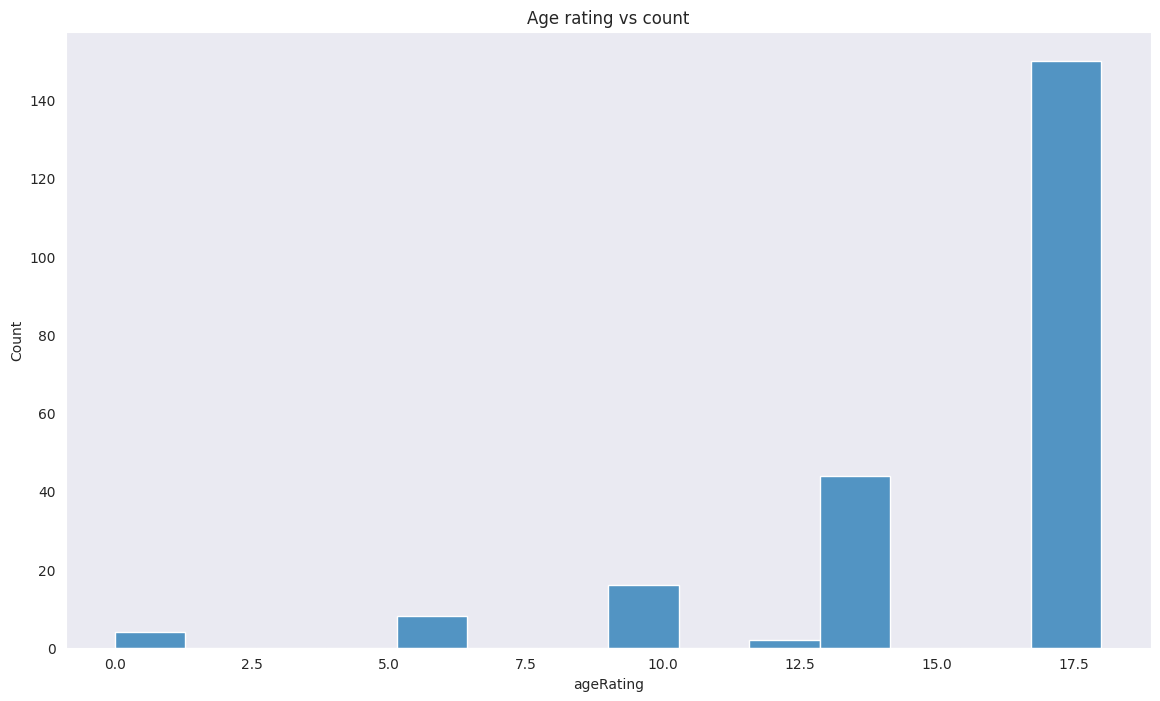

In [169]:
# let plot a hist again the count .
sns.set_style("dark");
plt.figure(figsize=(14, 8));

sns.histplot(x = "ageRating" , data = games_df)
plt.title('Age rating vs count')

Text(0.5, 1.0, 'Age rating vs count')

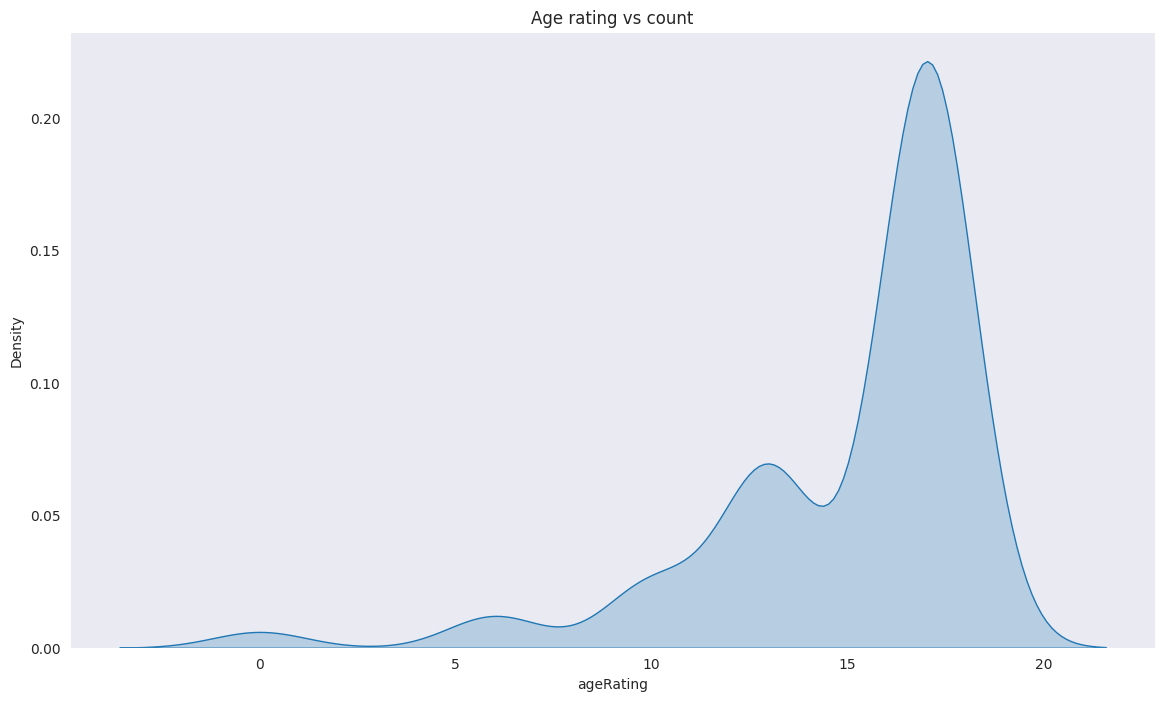

In [170]:
#kde plot
plt.figure(figsize=(14, 8));

sns.kdeplot(x = "ageRating" , data=games_df , fill=True)
plt.title('Age rating vs count')

<Axes: title={'center': 'Age rating vs count'}, xlabel='ageRating', ylabel='count'>

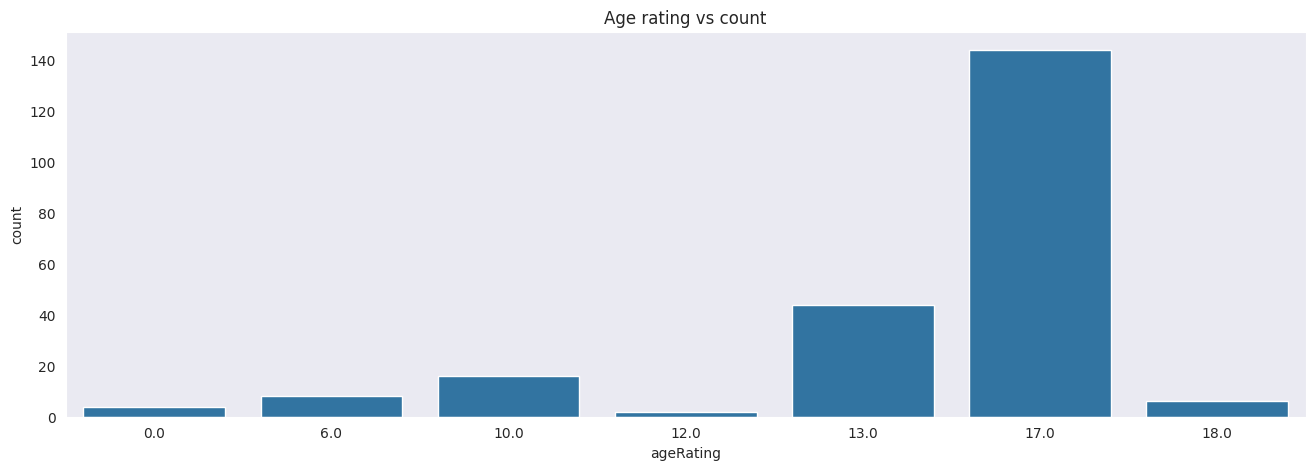

In [171]:
# count plot
plt.figure(figsize=(16 , 5));
plt.title("Age rating vs count")
sns.countplot( x = "ageRating" , data = games_df)

<Axes: title={'center': 'age rating box plot'}, xlabel='ageRating'>

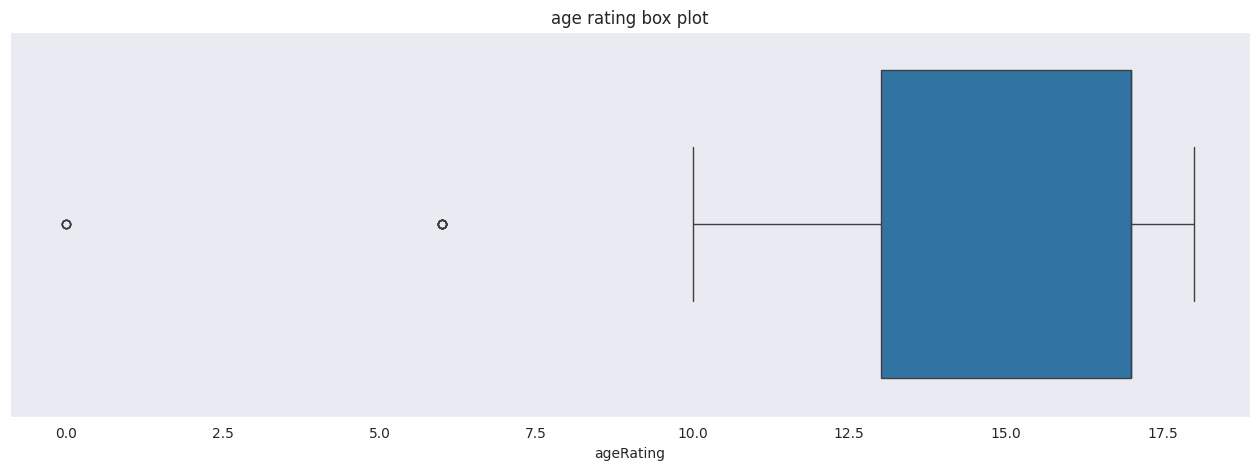

In [172]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("age rating box plot")
sns.boxplot(x=games_df["ageRating"])

max range at 12- 17

### Average rating

Text(0.5, 1.0, 'Average rating vs count')

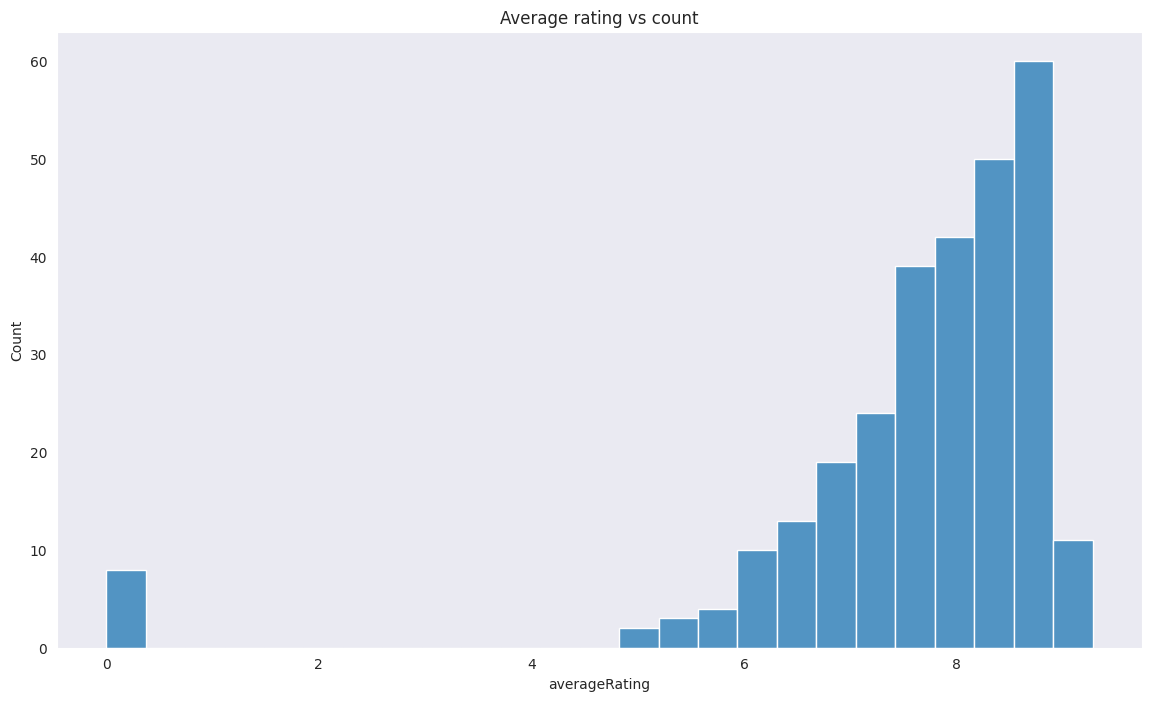

In [173]:
# lets focus on count vs the plot of average rating
plt.figure(figsize=(14, 8));

sns.histplot(x ="averageRating", data = games_df);
plt.title("Average rating vs count")

0 ia same as no rating and will be filtered out on training

<Axes: title={'center': 'average rating box plot'}, xlabel='averageRating'>

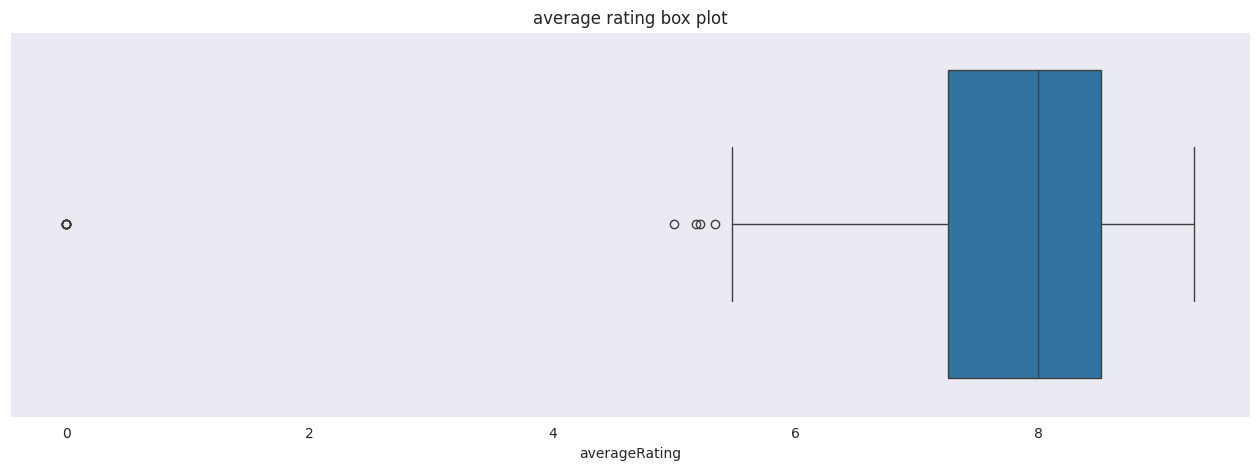

In [174]:
# let drawe the box plot these should not be outliers since we have a limt of 0-10
plt.figure(figsize=(16 , 5));
plt.title("average rating box plot")
sns.boxplot(x=games_df["averageRating"])

### created at

we will only simple draw a kde plot for visulaization , and we will not use this for training

Text(0.5, 1.0, 'created at vs count')

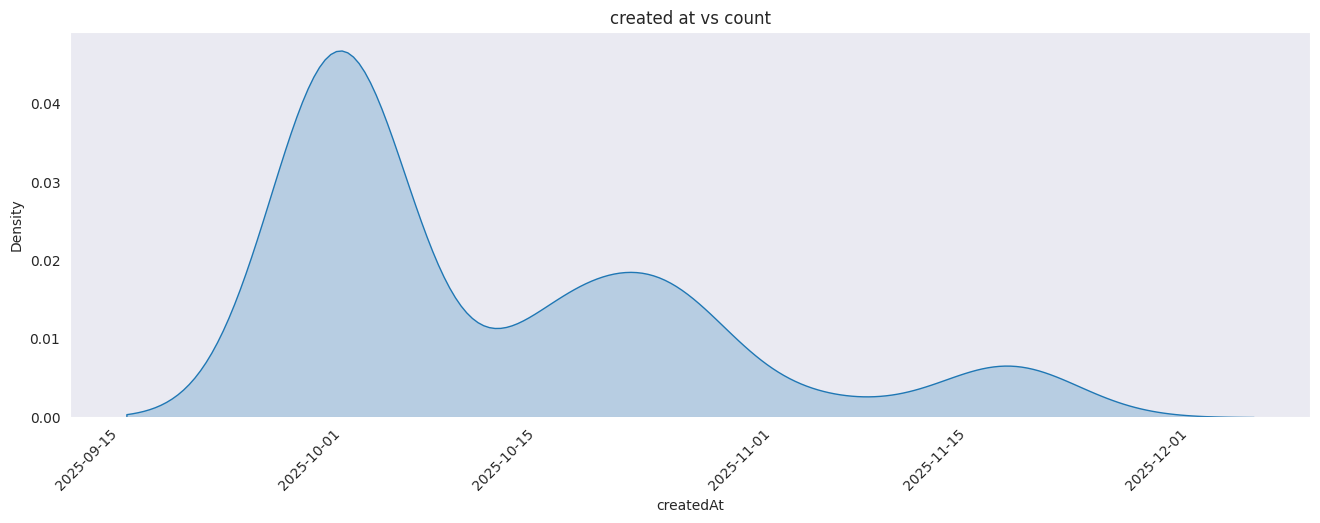

In [175]:
# create a kde plot
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "createdAt" , data = games_df , fill = True)
plt.xticks(rotation=45)
plt.title("created at vs count")

## Release date

<Axes: title={'center': 'release date  vs count'}, xlabel='releaseDate', ylabel='Count'>

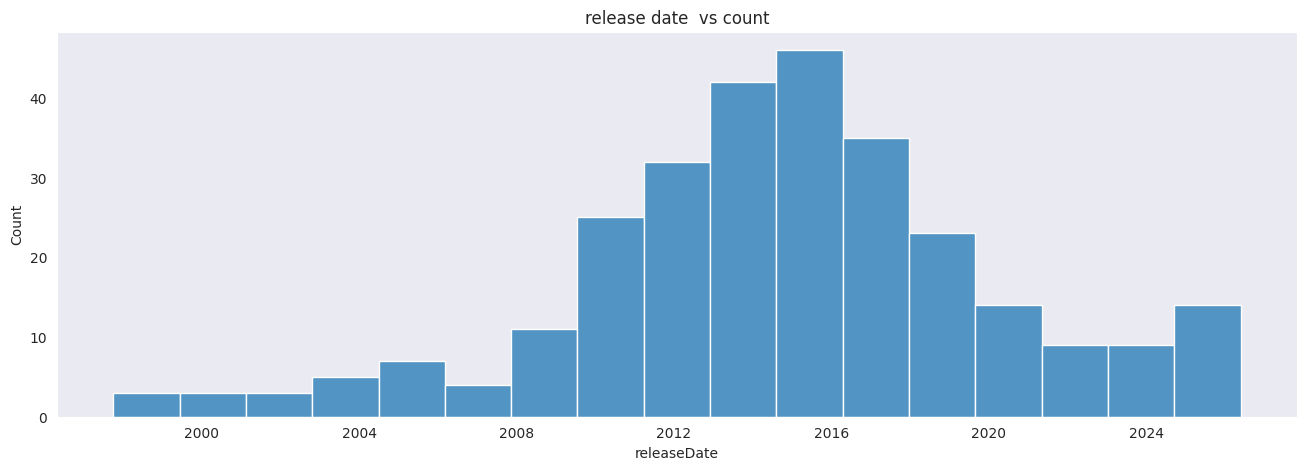

In [176]:
# hist graph for release date vs count
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

plt.title("release date  vs count")
sns.histplot( x = "releaseDate" , data = games_df)

Text(0.5, 1.0, 'release date  vs count')

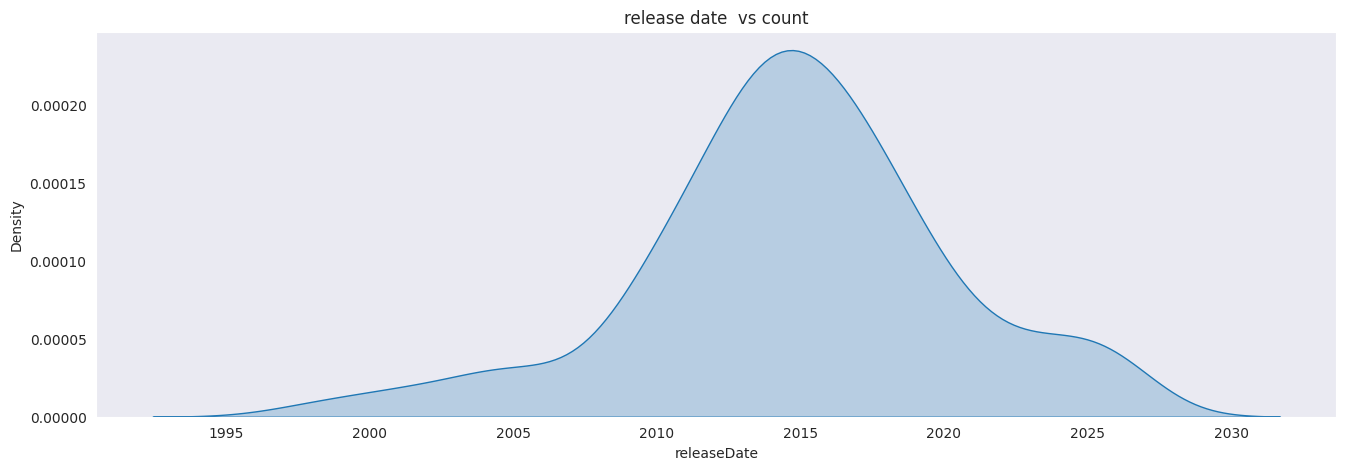

In [177]:
#kde plot
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "releaseDate" , data = games_df , fill = True)
plt.title("release date  vs count")

<Axes: title={'center': 'release box plot'}, xlabel='releaseDate'>

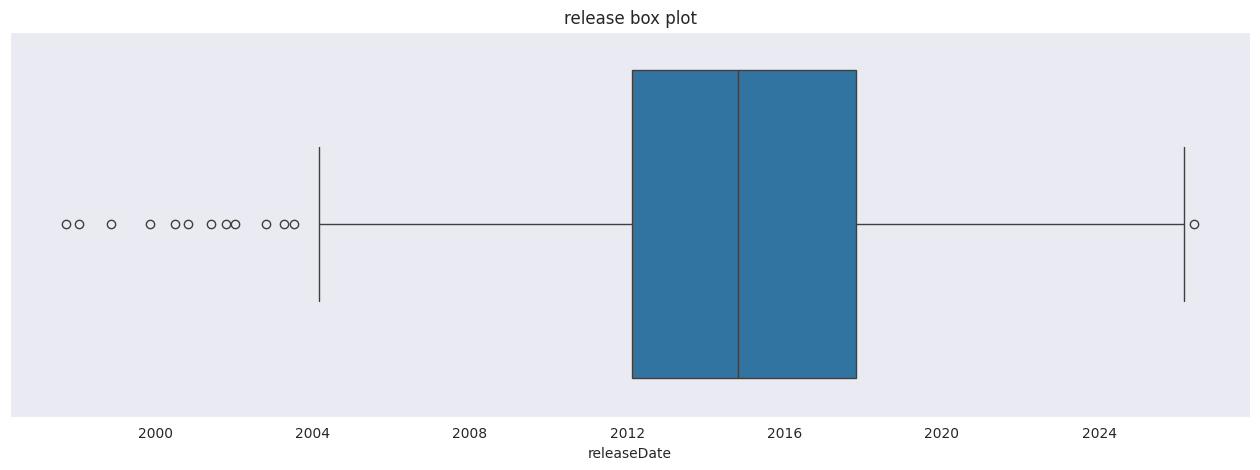

In [178]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("release box plot")
sns.boxplot(x=games_df["releaseDate"])

we will be imputing any outliers in the date range as per iqr

### Average play time

this can have a wide range .
we are currently storing data in minutes

<Axes: title={'center': 'Average run time vs count '}, xlabel='avgPlaytime', ylabel='Count'>

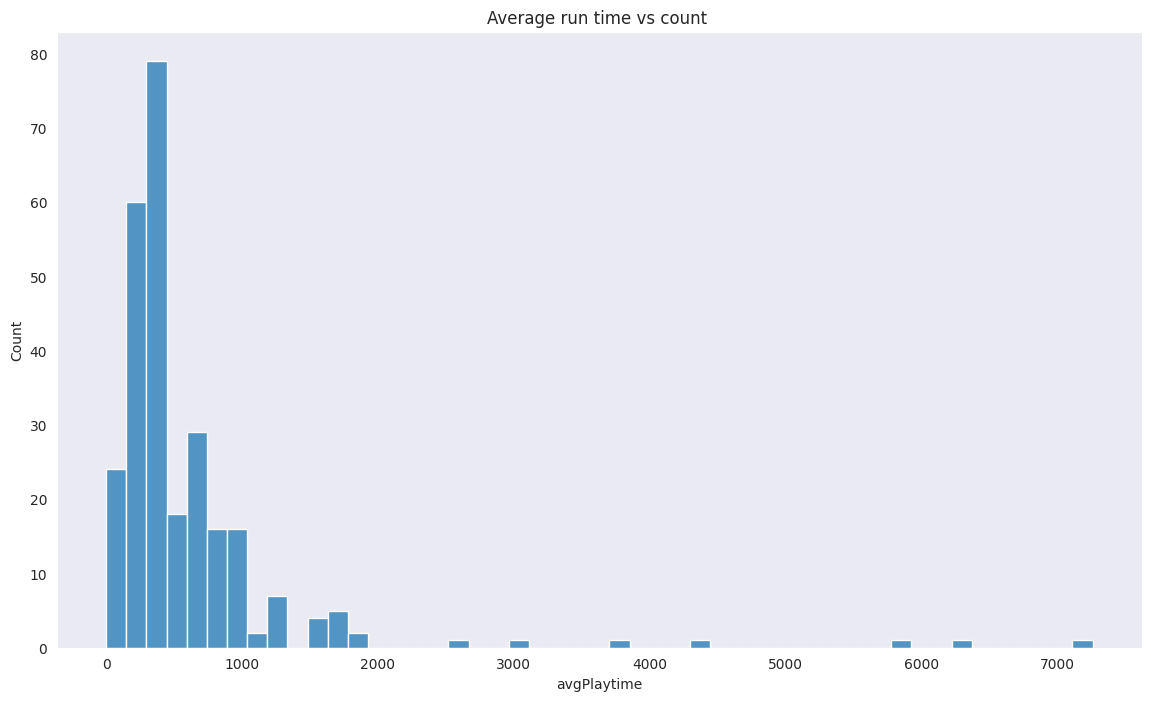

In [179]:
# lets plot hist plot for playtime
plt.figure(figsize=(14, 8));
plt.title("Average run time vs count ")
sns.histplot(x ="avgPlaytime" , data = games_df)

as we can observe there are some at very high play time . they hve to be handled in data cleaning a preocess

<Axes: title={'center': 'play time box plot'}, xlabel='avgPlaytime'>

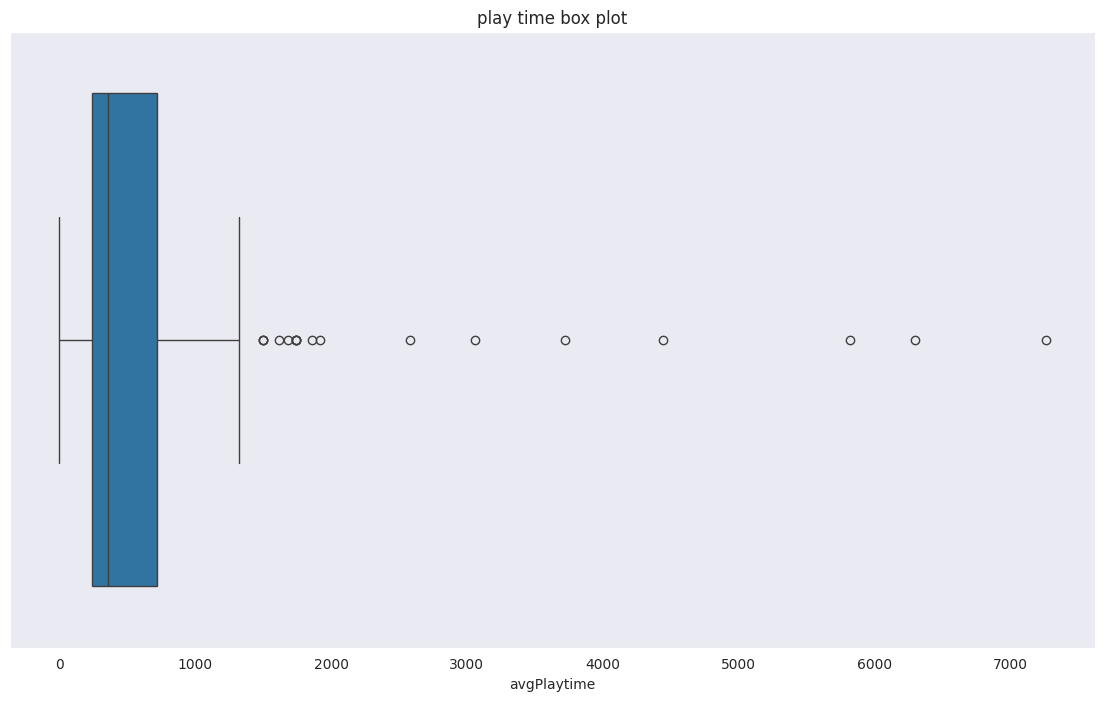

In [180]:
# lets also draw a box plot
plt.figure(figsize=(14 , 8));
plt.title("play time box plot")
sns.boxplot(x= games_df["avgPlaytime"])

## **Categorical Feature Analysis**

lets analyize our categorical data

In [181]:
# list of all the categorical data
cat_columns  = games_df.select_dtypes(include = "object")
cat_columns.columns

Index(['_id', 'title', 'description', 'genre', 'posterUrl', 'backdropUrl',
       'status', 'platforms', 'developer', 'youtubeVideoId'],
      dtype='object')

In [182]:
# let's create a copy of the data for analysis
games_analysis = games_df.copy()

### Genre

In [183]:
# replace the empty array oe missing values with unknown as place holder
games_analysis["genre_filled"] = games_analysis['genre'].apply(lambda x : x if isinstance(x, list) and len(x) > 0 else ["unknown"])

# explode and count includes placeholder
exploded_genre = games_analysis["genre_filled"].explode()
genre_counts = exploded_genre.value_counts()

genre_counts

,count
genre_filled,
Action,225
Adventure,92
RPG,83
Shooter,79
Indie,59
Simulation,20
Platformer,19
Strategy,18
Puzzle,10


action has be tagged a lot  , we can see that only 16 unique tags are used as of now

In [184]:
exploded_genre.unique()

array(['Action', 'Adventure', 'Indie', 'Platformer', 'Shooter', 'RPG',
       'Sports', 'Racing', 'Puzzle', 'Simulation', 'Strategy', 'Fighting',
       'Horror', 'Battle Royale', 'Stealth', 'Survival', 'Open World',
       'Visual Novel'], dtype=object)

In [185]:
# lets convert this to df to draw plots
genre_df = genre_counts.reset_index()
genre_df.columns = ["genre" , "count"]

genre_df

,genre,count
0,Action,225
1,Adventure,92
2,RPG,83
3,Shooter,79
4,Indie,59
5,Simulation,20
6,Platformer,19
7,Strategy,18
8,Puzzle,10
9,Fighting,8


<Axes: title={'center': 'Genere vs count '}, xlabel='Count', ylabel='Genre'>

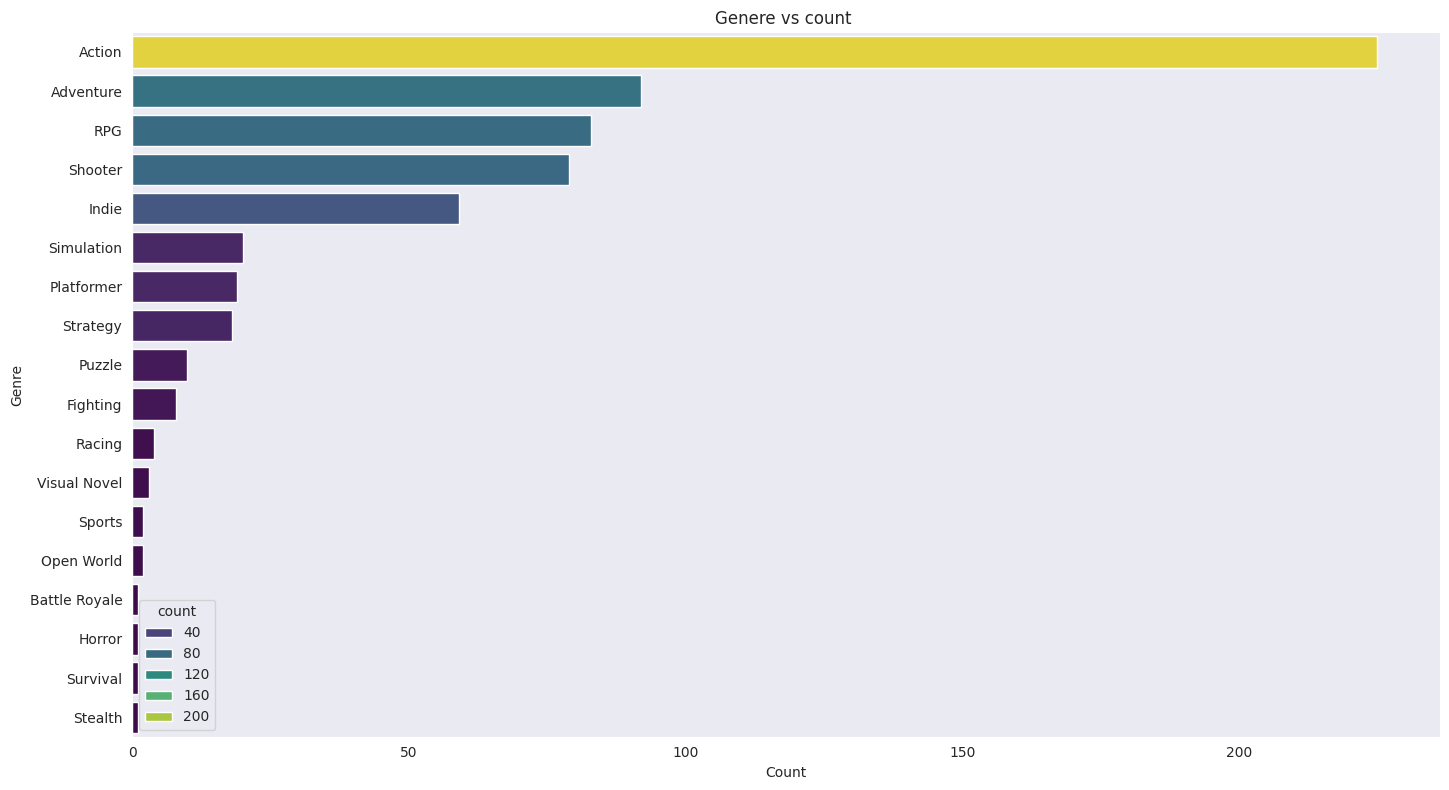

In [186]:
# plot the distribution plot with respect to count
sns.set_style("dark")
plt.figure(figsize=(14, 8));
plt.title("Genere vs count ")
plt.xlabel("Count");
plt.ylabel('Genre')
plt.tight_layout()
sns.barplot(x='count', y='genre', data=genre_df, palette='viridis' , hue="count")

### platforms

In [187]:
# Replace the empty array or the missing values with unknown as place holder
games_analysis["platforms_filled"] = games_analysis["platforms"].apply(lambda x : x  if isinstance(x , list)  and len(x) > 0 else ["unknown"])

# explode and count including the placeholder
exploded_platform = games_analysis["platforms_filled"].explode()
platform_counts = exploded_platform.value_counts()

## convert to df
platform_df = platform_counts.reset_index()
platform_df.columns = ["platform" , 'count']
platform_df

,platform,count
0,PC,273
1,Xbox One,176
2,PlayStation 4,172
3,Xbox 360,89
4,Nintendo Switch,88
5,PlayStation 3,83
6,Linux,78
7,PlayStation 5,54
8,Android,35
9,Xbox Series S/X,34


PC is used the most .

<Axes: title={'center': 'platform vs count '}, xlabel='Count', ylabel='Platfom'>

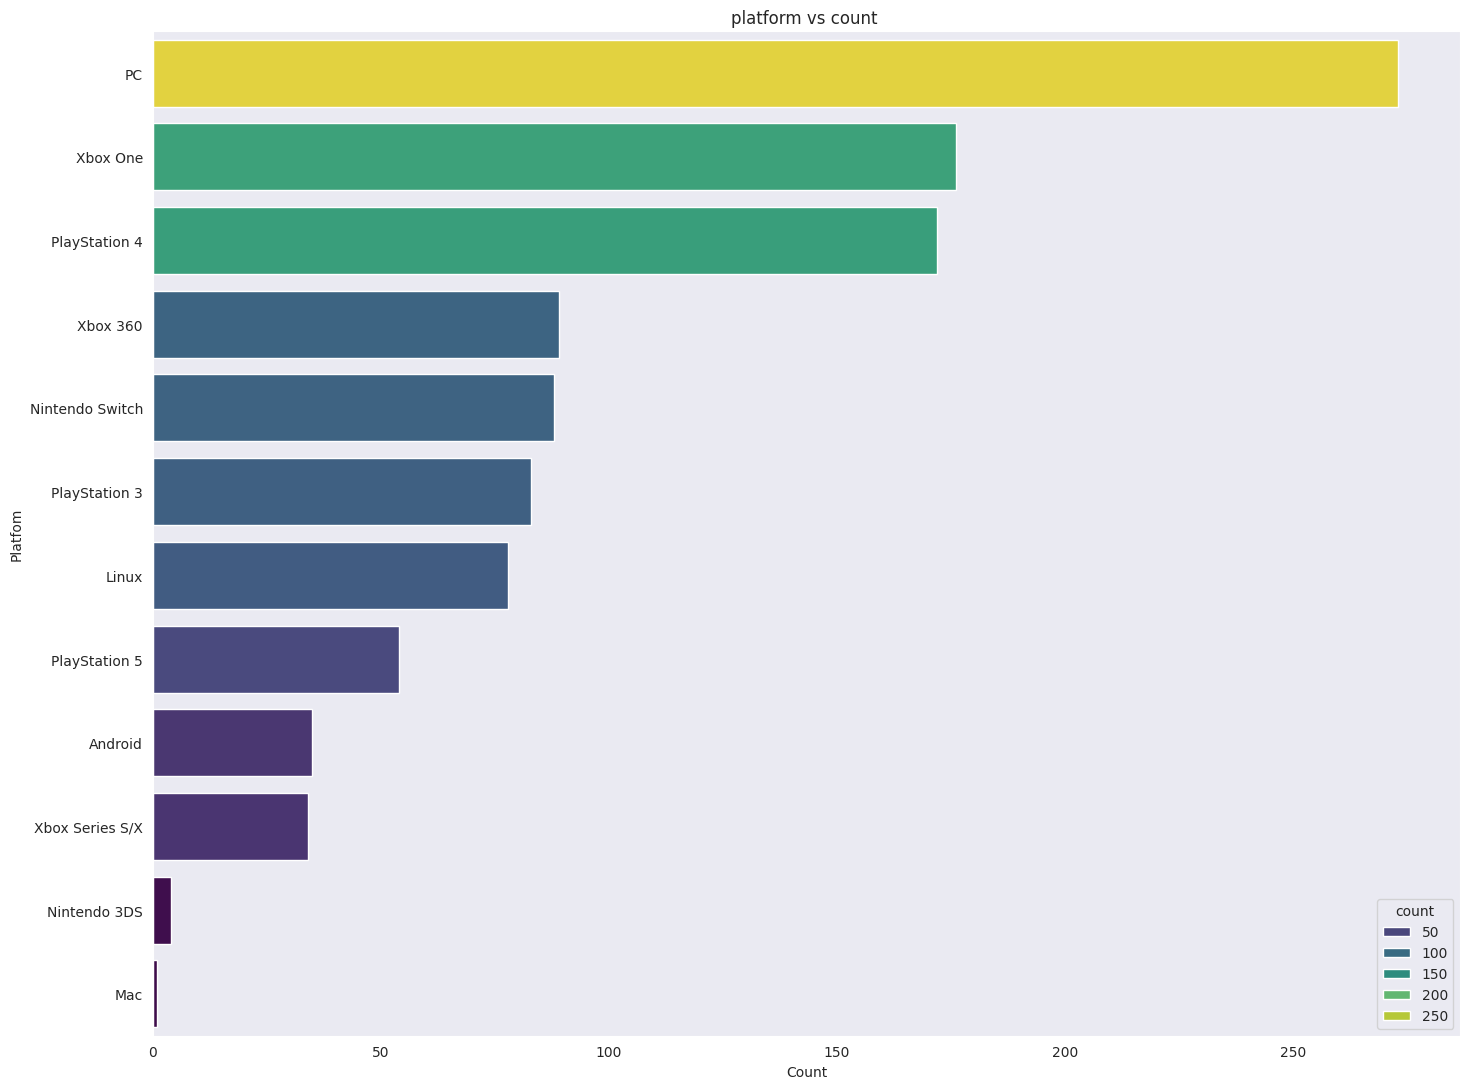

In [188]:
# plot the platform distribution plot with respect to count
sns.set_style("dark")
plt.figure(figsize=(14, 11));
plt.title("platform vs count ")
plt.xlabel("Count");
plt.ylabel('Platfom')
plt.tight_layout()
sns.barplot(x='count', y='platform', data=platform_df, palette='viridis' , hue="count")

### **isActive**

<Axes: xlabel='isActive', ylabel='count'>

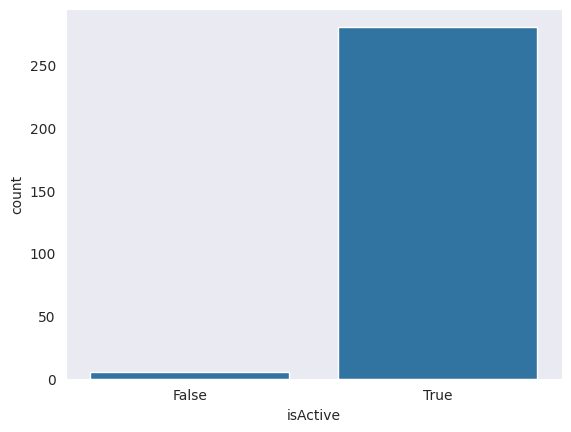

In [189]:
# lest check active and non active
sns.countplot(x= "isActive" , data = games_df )

there are few games set to inactive these will be removed from training .

### Average rating & genre

In [190]:
# explode genre
exploded_genre_rating =  games_analysis.explode("genre")

# lets drop any missing values
exploded_genre_rating = exploded_genre_rating.dropna(subset= ["genre" , "averageRating"])

# group by genere : calculate the count and mean of average rating
genre_stats = exploded_genre_rating.groupby("genre").agg(
    Count = ("genre" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

genre_stats

,genre,Count,AvgRating
0,Action,225,7.625956
1,Adventure,92,7.528043
2,Battle Royale,1,7.040000
3,Fighting,8,7.335000
4,Horror,1,6.960000
5,Indie,59,7.476610
6,Open World,2,4.410000
7,Platformer,19,8.055789
8,Puzzle,10,7.976000
9,RPG,83,7.740964


we can se bit of varied avg ratings

<Axes: title={'center': 'genere vs count with averating'}, xlabel='Count', ylabel='genre'>

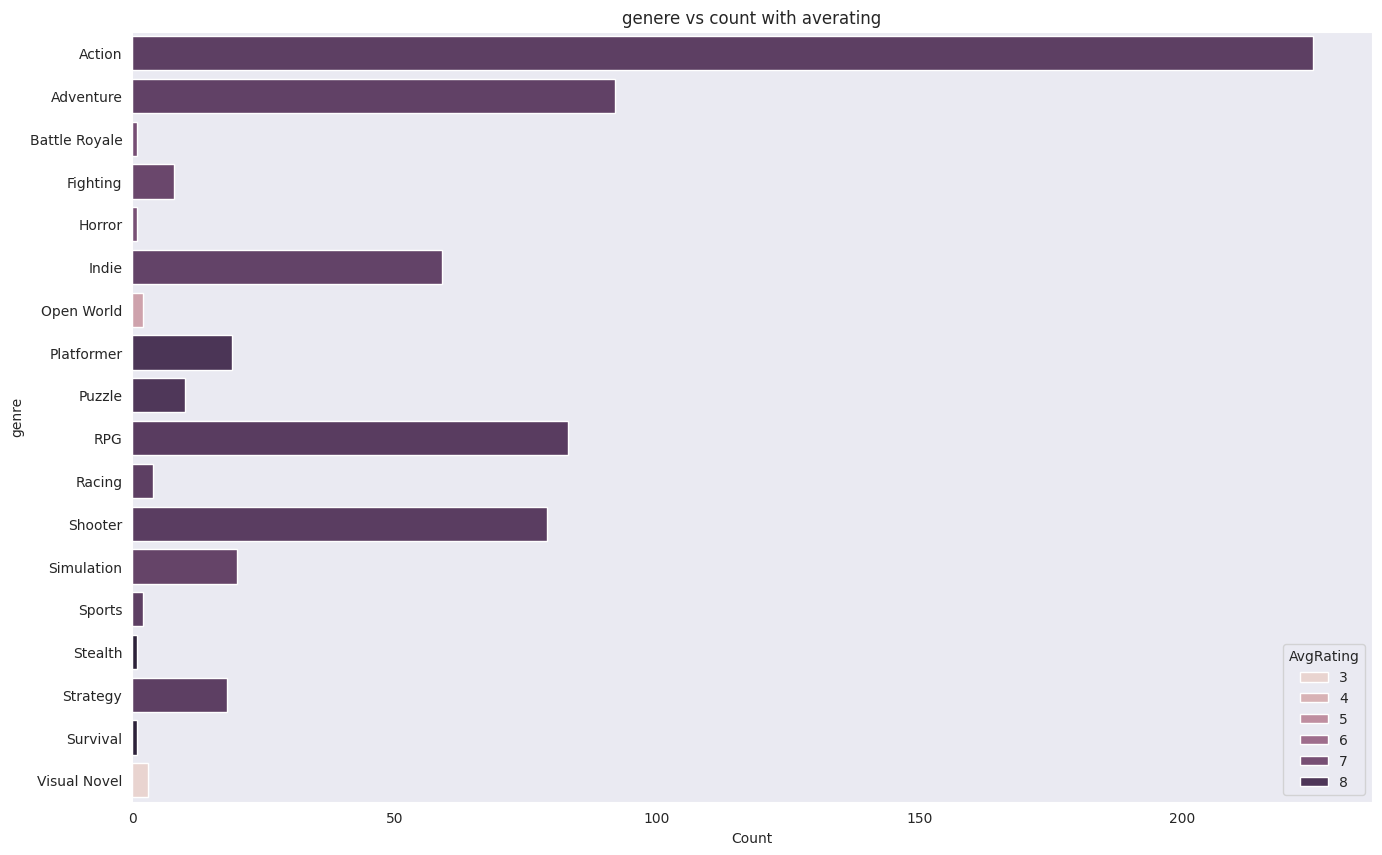

In [191]:
# lets plot a graph
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("genere vs count with averating")
sns.barplot(x= "Count" , y= "genre" , data = genre_stats , hue= "AvgRating")

open world and survivalgames have most rating

In [192]:
# sort by count
genre_stats = genre_stats.sort_values("Count" , ascending=False)

<Axes: title={'center': 'genere vs count with averating'}, xlabel='Count', ylabel='genre'>

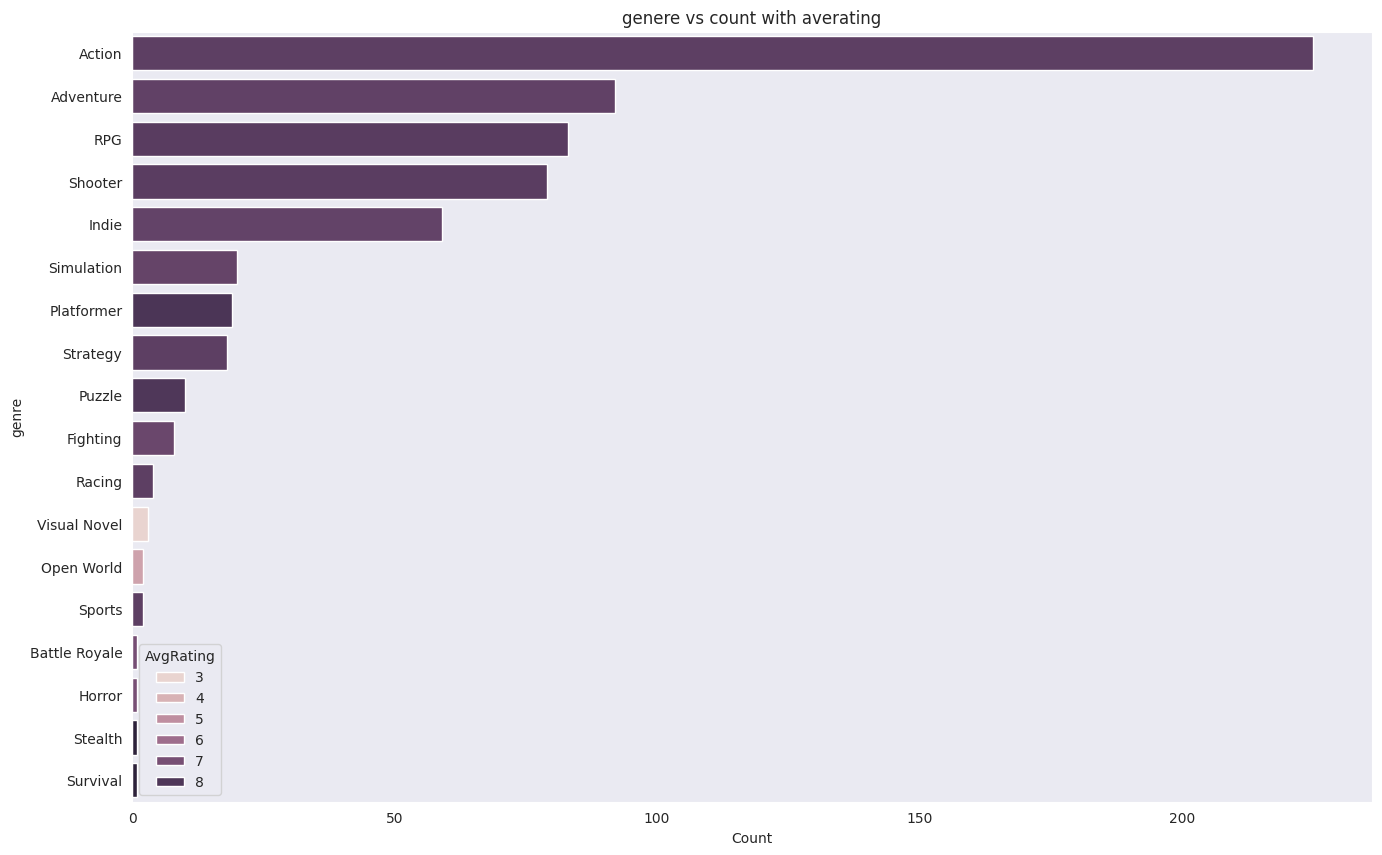

In [193]:
plt.figure(figsize=(16, 10));

plt.title("genere vs count with averating")
sns.barplot(x= "Count" , y= "genre" , data = genre_stats , hue= "AvgRating")

/tmp/ipython-input-3507860723.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


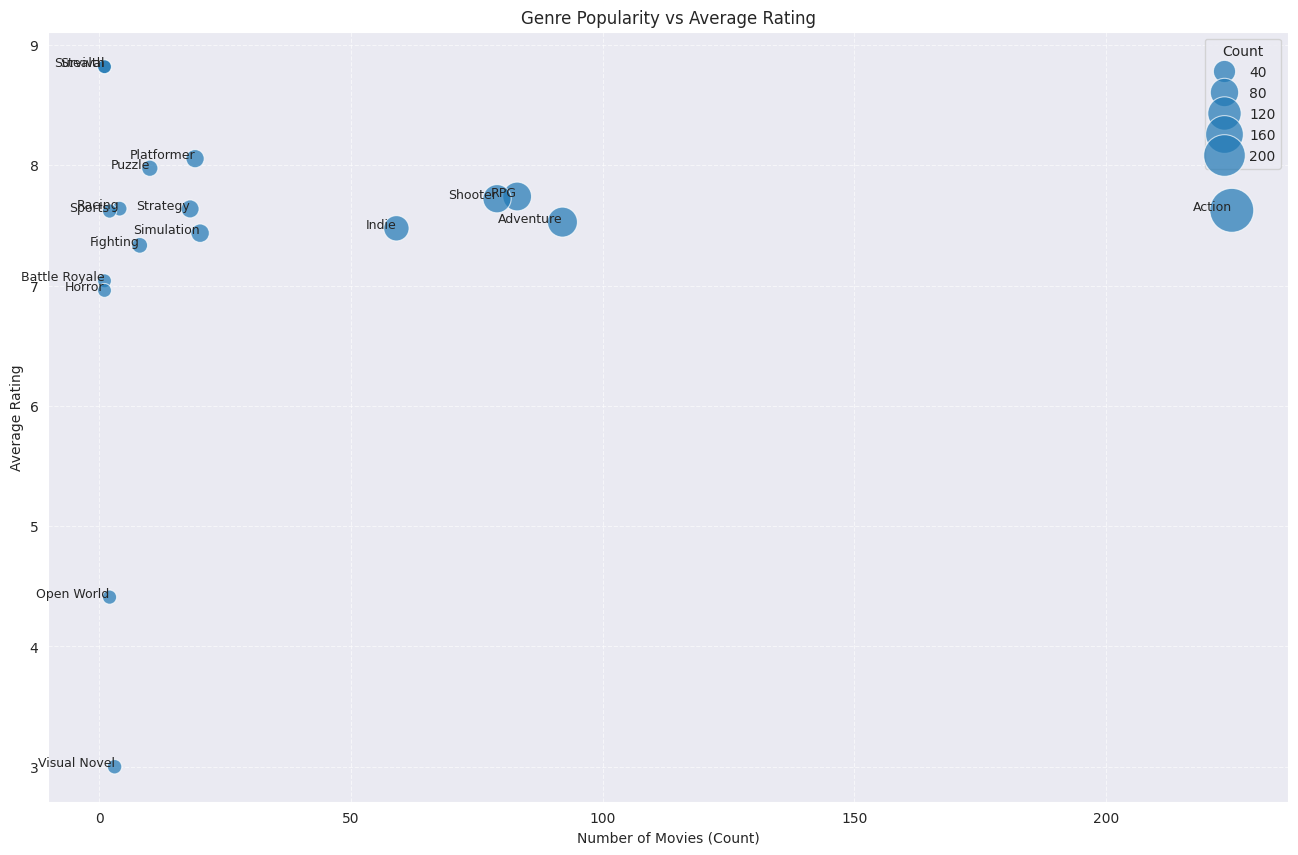

In [194]:
# lest also have a scatter plot  with respect to count and avergae rating on y
plt.figure(figsize=(16, 10));
sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )
# Label points with genre names for better readability
for i, row in genre_stats.iterrows():
    plt.text(row['Count'], row['AvgRating'], row['genre'], fontsize=9, ha='right')

plt.title('Genre Popularity vs Average Rating')
plt.xlabel('Number of Movies (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

/tmp/ipython-input-46704821.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


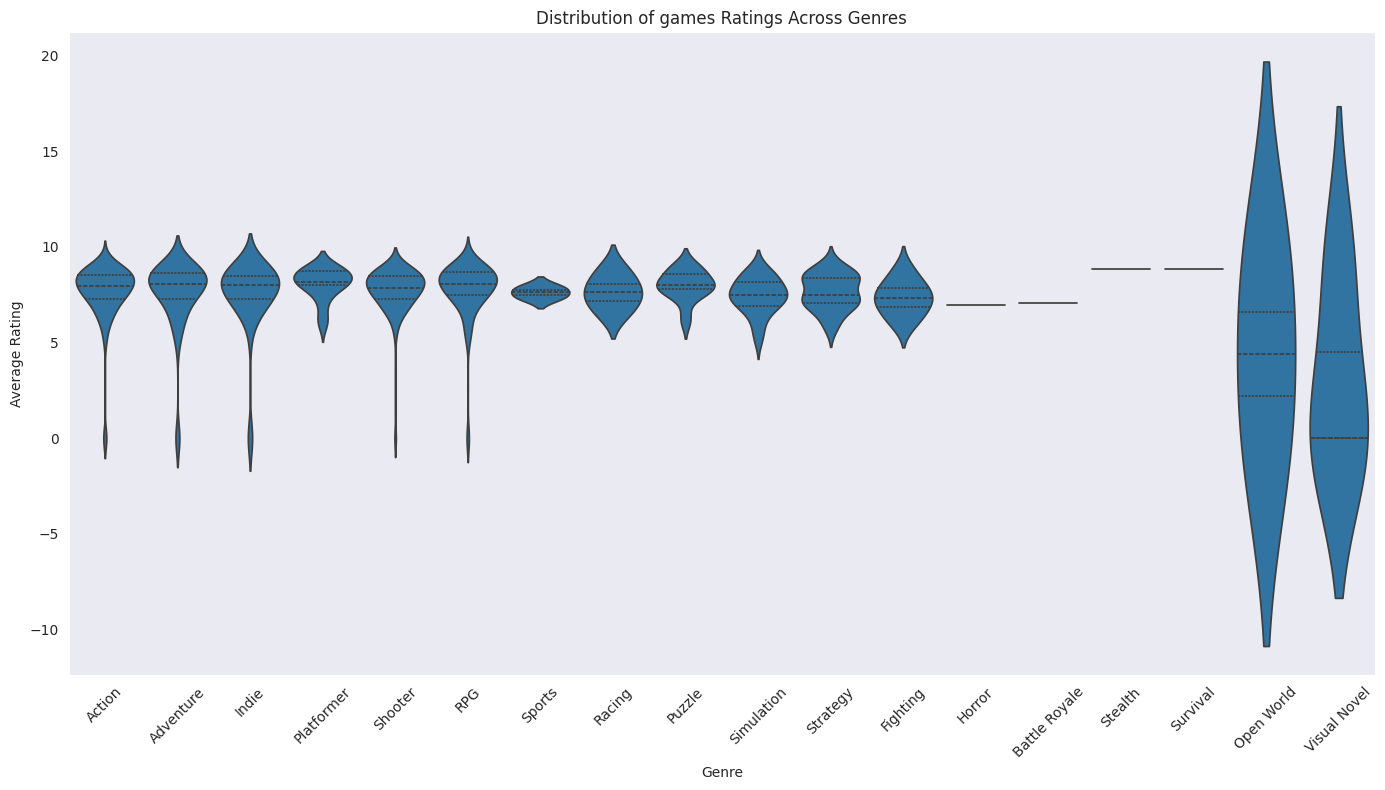

In [195]:
# violin plot

plt.figure(figsize=(14, 8));
sns.violinplot(
    x= "genre",
    y = "averageRating",
    data = exploded_genre_rating,
    inner= "quartile",
    scale= "width"
)

plt.xticks(rotation=45)
plt.title('Distribution of games Ratings Across Genres')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

we can make out theat the averag ewas high for open world and survival since they have very less count .

### Average rating & platforms

In [196]:
# explode platforms
exploded_platform_rating =  games_analysis.explode("platforms")

#lets drop any missing values
exploded_platform_rating= exploded_platform_rating.dropna(subset =["averageRating" , "platforms"])

# group platfoms and cal average ratings
platform_stats = exploded_platform_rating.groupby("platforms").agg(
    Count = ("platforms" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

platform_stats


,platforms,Count,AvgRating
0,Android,35,8.057143
1,Linux,78,7.687179
2,Mac,1,7.040000
3,Nintendo 3DS,4,8.190000
4,Nintendo Switch,88,7.959091
5,PC,273,7.664762
6,PlayStation 3,83,7.927229
7,PlayStation 4,172,7.927907
8,PlayStation 5,54,7.615926
9,Xbox 360,89,7.938652


In [197]:
# lets sort by count
platform_stats_sorted = platform_stats.sort_values("Count" , ascending=False)

<Axes: title={'center': 'platform vs count with averating'}, xlabel='Count', ylabel='platforms'>

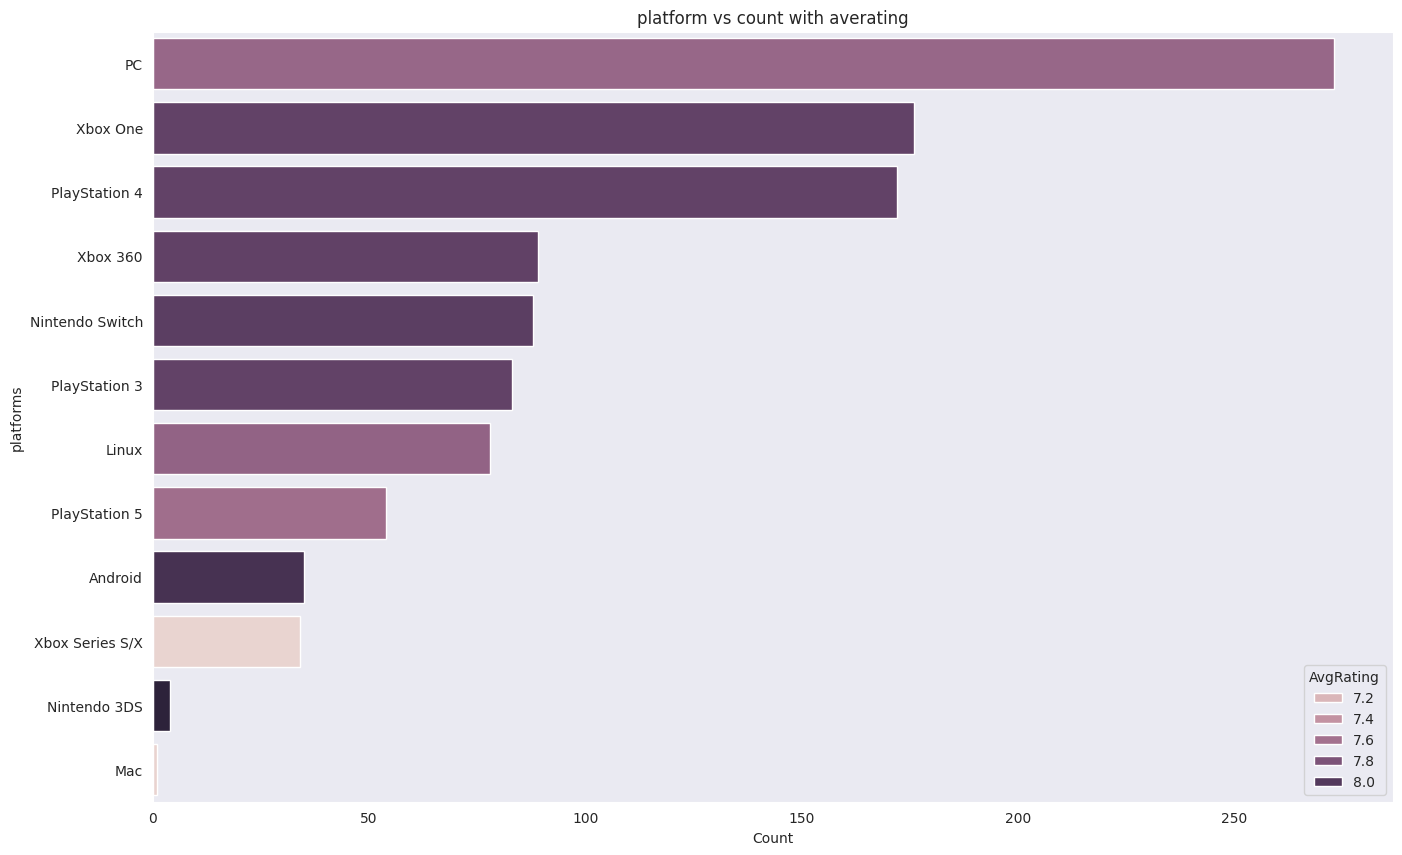

In [198]:
# lets plot the bar graph
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("platform vs count with averating")
sns.barplot(x= "Count" , y= "platforms" , data = platform_stats_sorted , hue= "AvgRating")

In [199]:
# lets sort by average rating
platform_stats_sorted = platform_stats.sort_values("AvgRating" , ascending=False)

<Axes: title={'center': 'platform vs count with averating'}, xlabel='Count', ylabel='platforms'>

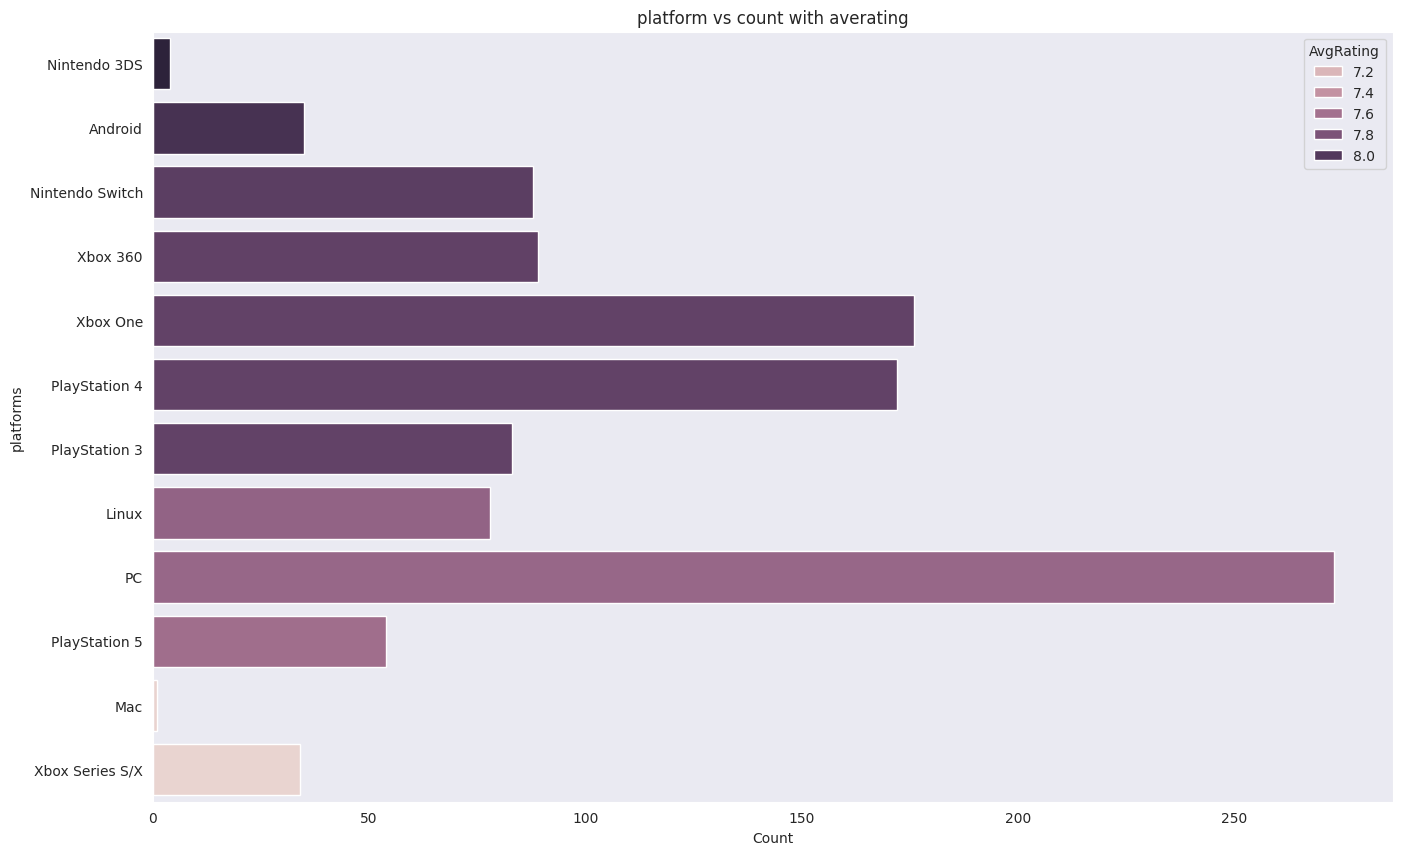

In [200]:
# lets plot the bar graph
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("platform vs count with averating")
sns.barplot(x= "Count" , y= "platforms" , data = platform_stats_sorted , hue= "AvgRating")

/tmp/ipython-input-2588869804.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = platform_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


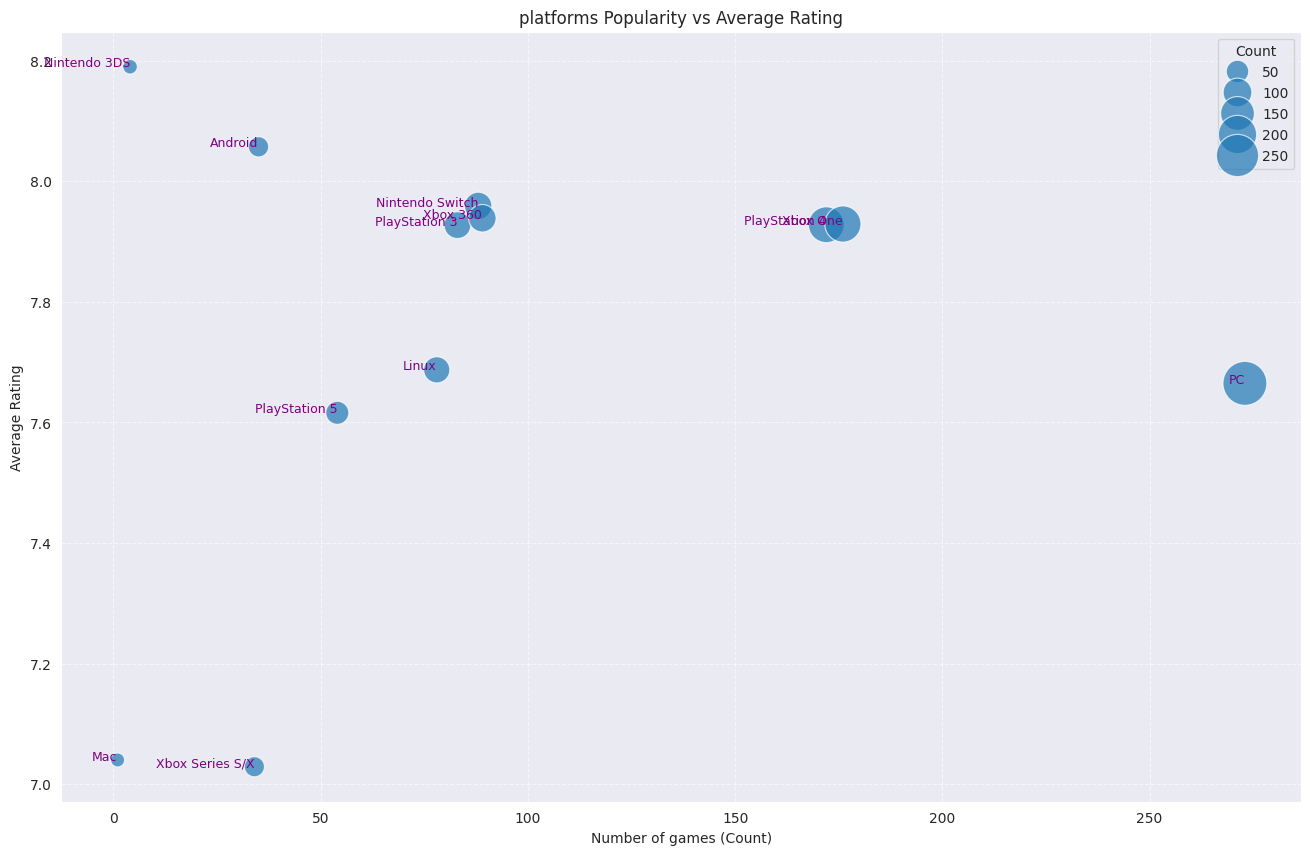

In [201]:
# let get a scatter plot
plt.figure(figsize=(16, 10));
sns.scatterplot(data = platform_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )

# Label points with tags names for better readability
for i, row in platform_stats.head(15).iterrows():
    plt.text(row['Count'], row['AvgRating'], row['platforms'], fontsize=9, ha='right' , color="purple")

plt.title('platforms Popularity vs Average Rating')
plt.xlabel('Number of games (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

/tmp/ipython-input-1623867833.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


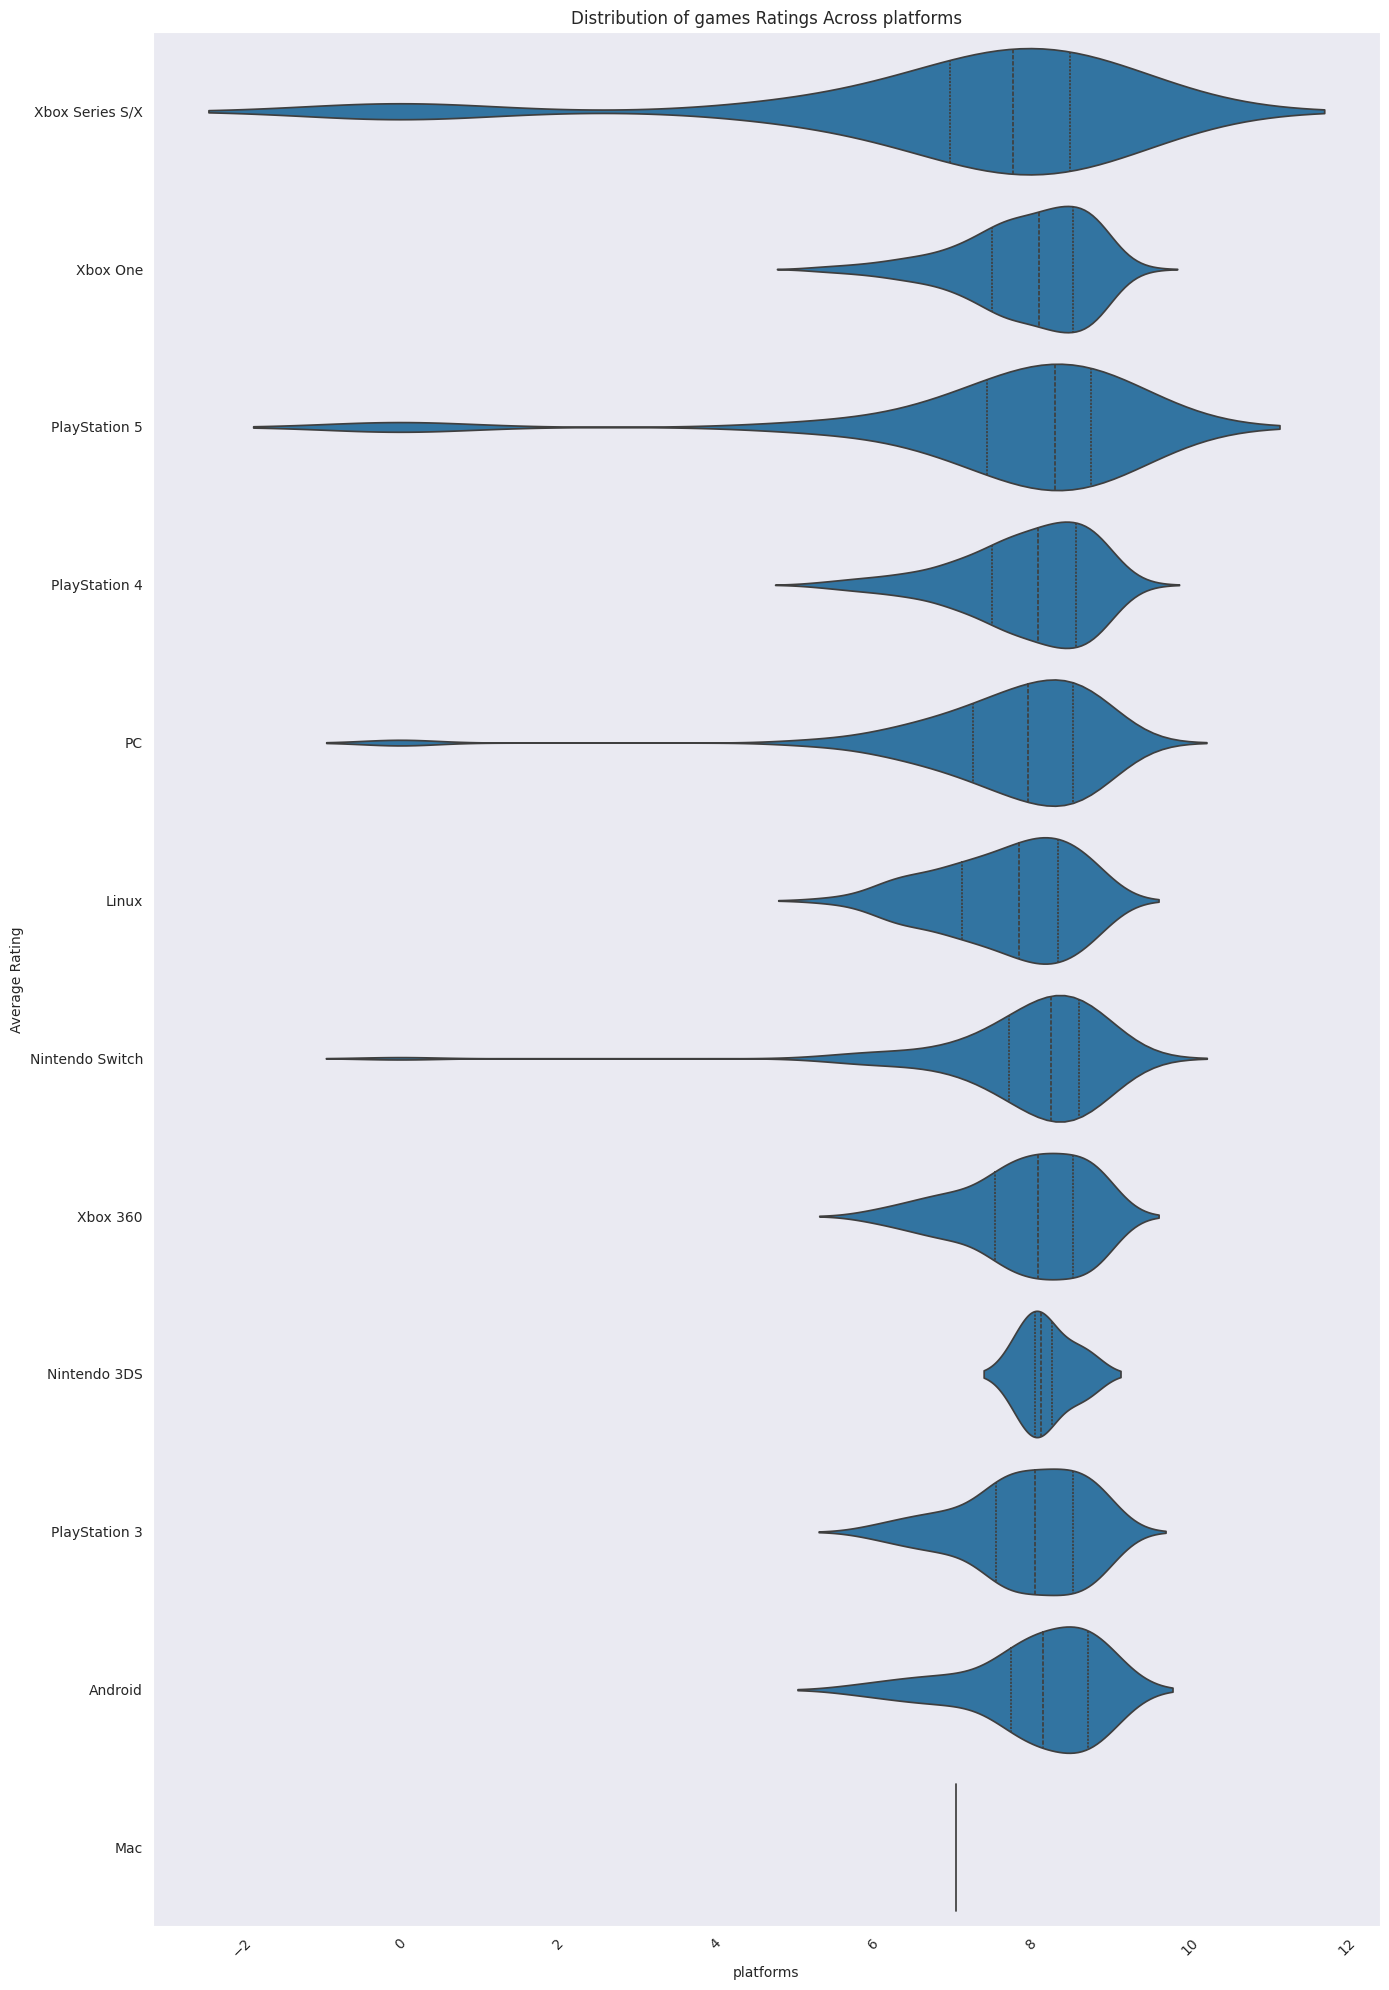

In [202]:
# let also go for a voiline plot for distribution visualization
plt.figure(figsize=(14, 20));
sns.violinplot(
    x= "averageRating",
    y="platforms",
    data = exploded_platform_rating,
    inner= "quartile",
    scale="width"
)

plt.xticks(rotation=45)
plt.title('Distribution of games Ratings Across platforms')
plt.xlabel('platforms')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

### Status

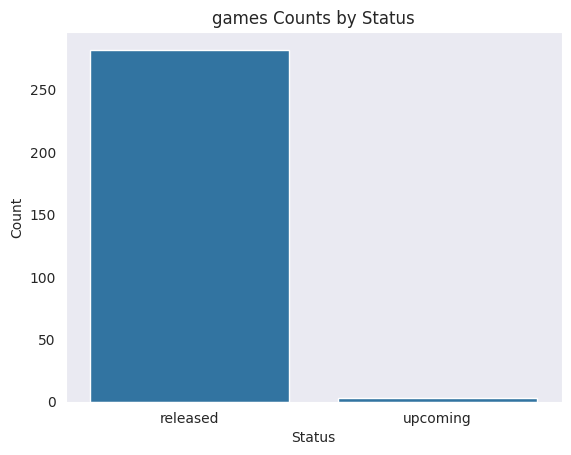

In [203]:
# lest plot count of released and upcomming.
status_counts = games_df['status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

sns.barplot(x='Status', y='Count', data=status_counts)
plt.title('games Counts by Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

we will skip status with respect to count , genere  till we get more counts of upcomming data

### Relationships & Correlations

/tmp/ipython-input-995751893.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["averageRating"].replace(0, np.nan, inplace=True)
/tmp/ipython-input-995751893.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

<Axes: title={'center': 'Scatter Plot of Average Rating vs Age Rating'}, xlabel='Age Rating', ylabel='Average Rating'>

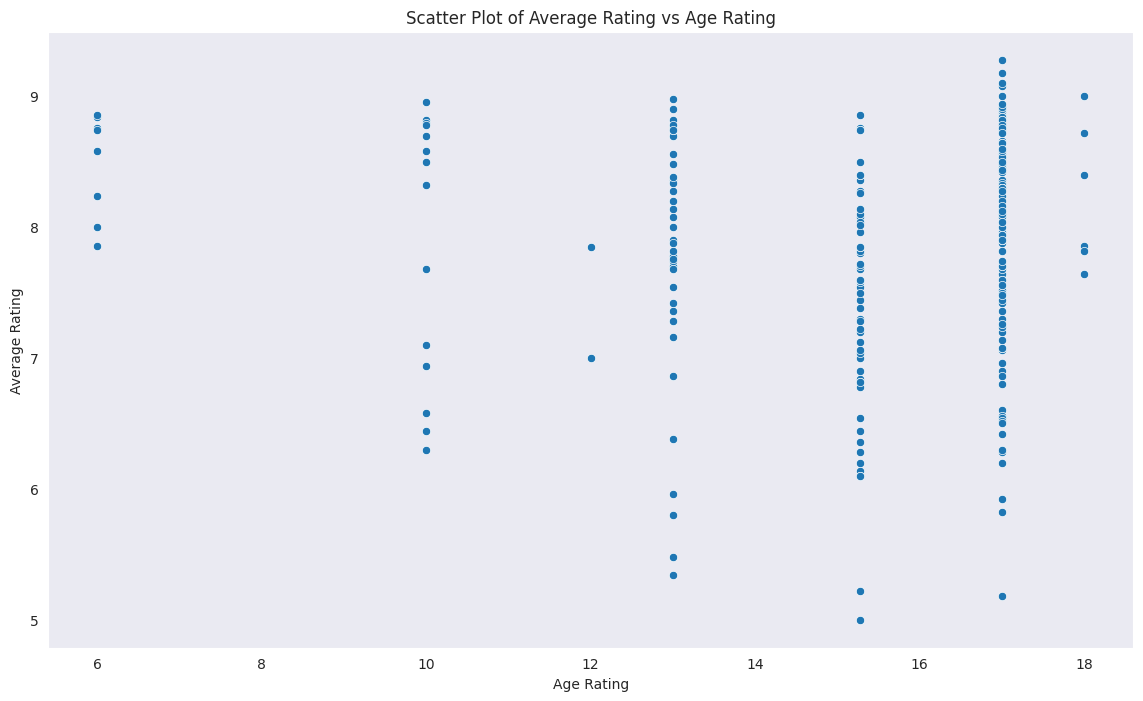

In [204]:
# age rating vs average rating corelation with scatter plot
plt.figure(figsize=(14, 8));

# lets have a temp df with nulls handled
df = games_df.copy()

# define imputers
impute_mean = SimpleImputer(strategy="mean")

# Replace zeros with np.nan for imputation
df["averageRating"].replace(0, np.nan, inplace=True)
df["ageRating"].replace(0, np.nan, inplace=True)

df["averageRating"] = impute_mean.fit_transform(df[["averageRating"]])
df["ageRating"] = impute_mean.fit_transform(df[["ageRating"]])

# now lets create the plot
plt.xlabel("Age Rating")
plt.ylabel("Average Rating")
plt.title("Scatter Plot of Average Rating vs Age Rating")
sns.scatterplot(x="ageRating" ,y = "averageRating" , data = df)

there is no relationship observed

In [205]:
# lets draw a pair plot of all numeric values , first lets drop non required columns
num_columns.drop(columns= [ "__v" ] , inplace=True)
num_columns.columns

Index(['averageRating', 'avgPlaytime', 'ageRating'], dtype='object')

In [206]:
# lets imput missing values for avgplay time
impute_mean = SimpleImputer(strategy="mean")
df["avgPlaytime"].replace(0, np.nan, inplace=True)
df["avgPlaytime"] = impute_mean.fit_transform(df[["avgPlaytime"]])


/tmp/ipython-input-840260952.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["avgPlaytime"].replace(0, np.nan, inplace=True)


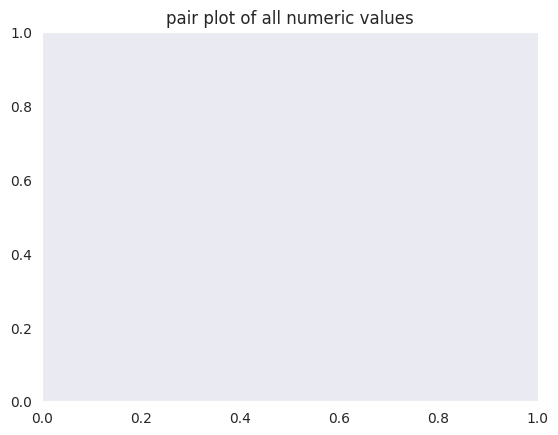

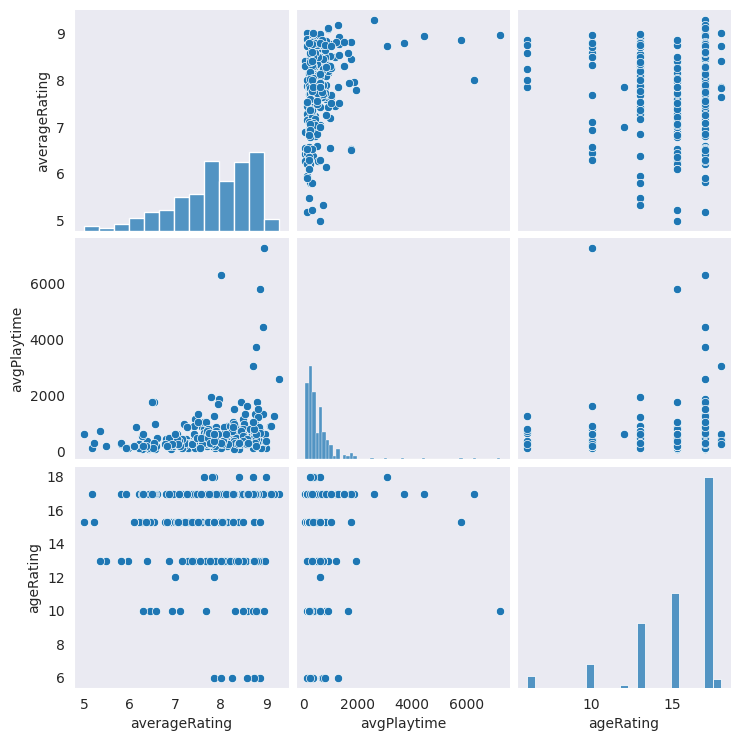

In [207]:

# lets now plot the pair plot
plt.title("pair plot of all numeric values")
sns.pairplot( df[num_columns.columns])

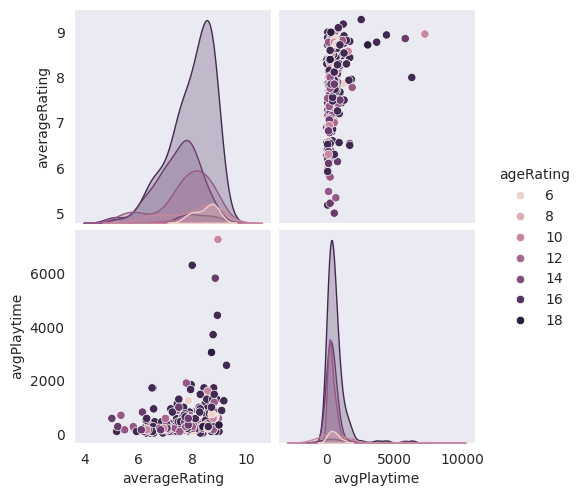

In [208]:
# with age as hue
sns.pairplot( df[num_columns.columns] , hue= "ageRating")

Text(0.5, 1.0, 'Correlation Heatmap numeric data')

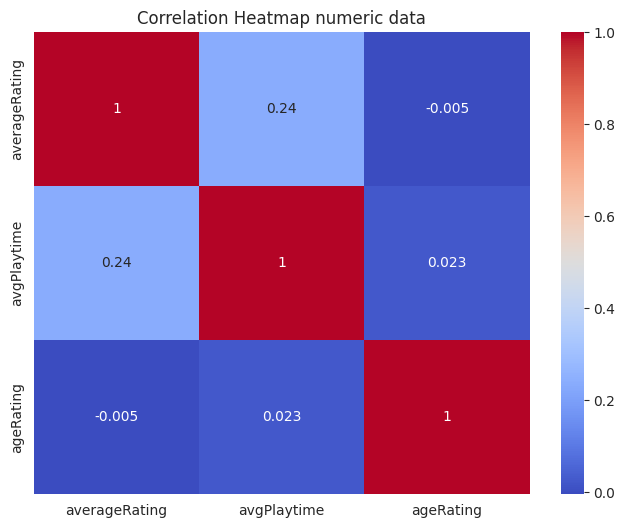

In [209]:
# lets plot a corr realtion heat map

corr_matrix = df[num_columns.columns].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap numeric data")

no strong relational data found .

# Data cleaning

now lets clear all the unwanted data from the data frame as per our observation and also impute missing values .

In [210]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             285 non-null    object             
 1   title           285 non-null    object             
 2   description     285 non-null    object             
 3   averageRating   285 non-null    float64            
 4   genre           285 non-null    object             
 5   releaseDate     285 non-null    datetime64[ns, UTC]
 6   posterUrl       285 non-null    object             
 7   backdropUrl     285 non-null    object             
 8   isActive        285 non-null    bool               
 9   status          285 non-null    object             
 10  platforms       285 non-null    object             
 11  avgPlaytime     269 non-null    float64            
 12  developer       285 non-null    object             
 13  youtubeVideoId  285 non-null    obj

In [211]:
# lets create a copy of the data
df_clean = games_df.copy()

#lets remove any inactive games before procceding further
df_clean = df_clean[df_clean["isActive"] == True]

# lest first define all the columns to drop
columns_to_drop = [
    '__v',           # MongoDB version key mot importent
    'updatedAt',     # Not needed for training
    'backdropUrl',   # URL - not useful for training
    'posterUrl',     # URL - not useful for training
    'isActive',      # We only want active data
    'youtubeVideoId',# Video ID - not useful for training
    "createdAt",     # not important data can be misleading
]

# drop all the columsn
df_clean = df_clean.drop(columns= columns_to_drop)
print(f"Shape before dropping: {df_clean.shape}")
print(f"Shape after dropping: {df_clean.shape}")

Shape before dropping: (280, 11)
Shape after dropping: (280, 11)


In [212]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 0 to 284
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   _id            280 non-null    object             
 1   title          280 non-null    object             
 2   description    280 non-null    object             
 3   averageRating  280 non-null    float64            
 4   genre          280 non-null    object             
 5   releaseDate    280 non-null    datetime64[ns, UTC]
 6   status         280 non-null    object             
 7   platforms      280 non-null    object             
 8   avgPlaytime    268 non-null    float64            
 9   developer      280 non-null    object             
 10  ageRating      222 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(3), object(7)
memory usage: 26.2+ KB


lets take care of numeric value having missing data

In [213]:
# lets replace 0 with nan for averageRating , ageRating , avgPlaytime
# since in our application this are equilant to nan

df_clean["averageRating"].replace(0, np.nan, inplace=True)
df_clean["ageRating"].replace(0, np.nan, inplace=True)
df_clean["avgPlaytime"].replace(0, np.nan, inplace=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 0 to 284
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   _id            280 non-null    object             
 1   title          280 non-null    object             
 2   description    280 non-null    object             
 3   averageRating  276 non-null    float64            
 4   genre          280 non-null    object             
 5   releaseDate    280 non-null    datetime64[ns, UTC]
 6   status         280 non-null    object             
 7   platforms      280 non-null    object             
 8   avgPlaytime    267 non-null    float64            
 9   developer      280 non-null    object             
 10  ageRating      219 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(3), object(7)
memory usage: 26.2+ KB


/tmp/ipython-input-828503176.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["averageRating"].replace(0, np.nan, inplace=True)
/tmp/ipython-input-828503176.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [214]:
# lets set up imputer
imputer_mean = SimpleImputer(strategy="mean")

# impute only necessary columns
df_clean[["averageRating" , "ageRating" , "avgPlaytime"]] = imputer_mean.fit_transform(df_clean[["averageRating" , "ageRating" , "avgPlaytime"]])

In [215]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 0 to 284
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   _id            280 non-null    object             
 1   title          280 non-null    object             
 2   description    280 non-null    object             
 3   averageRating  280 non-null    float64            
 4   genre          280 non-null    object             
 5   releaseDate    280 non-null    datetime64[ns, UTC]
 6   status         280 non-null    object             
 7   platforms      280 non-null    object             
 8   avgPlaytime    280 non-null    float64            
 9   developer      280 non-null    object             
 10  ageRating      280 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(3), object(7)
memory usage: 26.2+ KB


In [216]:
# lest check if we have any null
null_counts = df_clean[num_columns.columns].isnull().sum()
null_counts

,0
averageRating,0
avgPlaytime,0
ageRating,0


In [217]:
# lets now handle any missing data in release date

# currently we dont have any missing value but it can be there in future
# lets imput this with median()
median_date = df_clean['releaseDate'].median()
df_clean['releaseDate'] = df_clean['releaseDate'].fillna(median_date)
df_clean['releaseDate'].isnull().sum()

np.int64(0)

Now lets go on and deal with missing values in our array type feilds in case they are toatlly missing or an empty array lest fill them up by unknown . and add a feild with IsMissing and set to true

In [218]:
# for doing this lets create a function since we have a lot of columns
def impute_array_col (df , col_name , fill_value = ["Unknown"]):
  # impute the missing values first
  filled_col = df[col_name].apply(lambda x: x if isinstance(x , list) and len(x) > 0 else fill_value)
  # create a flag column for missing data
  flag_col = df[col_name].apply(lambda x : not isinstance(x , list) or len(x) == 0)
  # assign it back to the main dataframe
  df[col_name] = filled_col
  df[col_name + "IsMissing"] = flag_col
  return df

In [219]:
# lets check our categorical columns
cat_cols = df_clean.select_dtypes(include="object")
cat_cols.columns

Index(['_id', 'title', 'description', 'genre', 'status', 'platforms',
       'developer'],
      dtype='object')

In [220]:
# lets only imput for necessary cols
impute_array_col(df = df_clean , col_name = "genre");
impute_array_col(df = df_clean , col_name = "platforms");

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 0 to 284
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   _id                 280 non-null    object             
 1   title               280 non-null    object             
 2   description         280 non-null    object             
 3   averageRating       280 non-null    float64            
 4   genre               280 non-null    object             
 5   releaseDate         280 non-null    datetime64[ns, UTC]
 6   status              280 non-null    object             
 7   platforms           280 non-null    object             
 8   avgPlaytime         280 non-null    float64            
 9   developer           280 non-null    object             
 10  ageRating           280 non-null    float64            
 11  genreIsMissing      280 non-null    bool               
 12  platformsIsMissing  280 non-null    bool 

In [221]:
# lets handle string values now and  we only have description that can be missing .
df_clean["description"] = df_clean["description"].apply(lambda x : x if x.strip() else "No description available")
df_clean["description"].info()

<class 'pandas.core.series.Series'>
Index: 280 entries, 0 to 284
Series name: description
Non-Null Count  Dtype 
--------------  ----- 
280 non-null    object
dtypes: object(1)
memory usage: 4.4+ KB


In [222]:
# lets handle outliers for avgplayTime other numeric fileds already ahave boundaries

Q1 = df_clean["avgPlaytime"].quantile(0.10)#first quartile)
Q3 = df_clean["avgPlaytime"].quantile(0.85)#third quartile

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean["avgPlaytime"] = df_clean["avgPlaytime"].clip(lower= lower_bound , upper=upper_bound)

df_clean["avgPlaytime"].head()

,avgPlaytime
0,780.0
1,600.0
2,1740.0
3,900.0
4,840.0


# Feature engineering

In [223]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 0 to 284
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   _id                 280 non-null    object             
 1   title               280 non-null    object             
 2   description         280 non-null    object             
 3   averageRating       280 non-null    float64            
 4   genre               280 non-null    object             
 5   releaseDate         280 non-null    datetime64[ns, UTC]
 6   status              280 non-null    object             
 7   platforms           280 non-null    object             
 8   avgPlaytime         280 non-null    float64            
 9   developer           280 non-null    object             
 10  ageRating           280 non-null    float64            
 11  genreIsMissing      280 non-null    bool               
 12  platformsIsMissing  280 non-null    bool 

Here, we will focus on transforming the information from our columns into a format that is more useful for our model. We'll start by working with the array fields first.

In [224]:
# first lest encode our status to binary since we have only 2 unique status
df_clean["status"].unique()

array(['released'], dtype=object)

In [225]:
# we will be encoding released = 1 , upcoming = 0
# binary encoding

df_clean["status"]  = (df_clean["status"] == "released").astype(int)

df_clean["status"].head()

,status
0,1
1,1
2,1
3,1
4,1


now lets handle columns like platform , genre and developer we will be multi hot encoding them .

In [226]:
# lets first handle the geners
# we will multi encode them
mlb_genre = MultiLabelBinarizer()
geners_encoded = mlb_genre.fit_transform(df_clean["genre"]);
genres_df = pd.DataFrame(geners_encoded, columns=mlb_genre.classes_)

# we drop unknown since its not required
genres_df.drop(columns=["Unknown"] , inplace=True , errors="ignore")

genres_df.head()

,Action,Adventure,Battle Royale,Fighting,Horror,Indie,Open World,Platformer,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Stealth,Strategy,Survival,Visual Novel
0,1,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
3,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [227]:
# lets handle the platforms
mlb_platforms =  MultiLabelBinarizer()
platform_encoded = mlb_platforms.fit_transform(df_clean["platforms"]);
platforms_df = pd.DataFrame(platform_encoded , columns= mlb_platforms.classes_)

# we drop unknown since its not required
platforms_df.drop(columns=["Unknown"] , inplace=True , errors="ignore")

platforms_df.head(10)

,Android,Linux,Mac,Nintendo 3DS,Nintendo Switch,PC,PlayStation 3,PlayStation 4,PlayStation 5,Xbox 360,Xbox One,Xbox Series S/X
0,0,1,0,0,1,1,0,1,1,0,1,1
1,0,0,0,0,1,1,0,1,0,0,1,0
2,0,0,0,0,1,1,0,1,1,0,1,1
3,1,1,0,1,1,1,1,1,0,1,1,0
4,0,1,0,0,0,1,0,0,0,0,0,0
5,0,0,0,0,1,1,0,1,1,0,1,1
6,0,0,0,0,0,1,1,0,0,1,1,0
7,0,1,0,0,1,1,0,1,0,0,1,0
8,0,0,0,0,0,1,0,1,0,0,0,0
9,0,0,0,0,0,1,0,0,0,1,0,0


In [228]:
df_clean = df_clean.reset_index(drop=True)
genres_df = genres_df.reset_index(drop=True)

# now lets add all the data to df_clean
df_clean_combined = df_clean.join([ platforms_df, genres_df])

# lest drop the columns we dont require like tags , languages and genere
df_clean_combined.drop(columns= ["platforms" , "genre" ] , inplace=True)

df_clean_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   _id                 280 non-null    object             
 1   title               280 non-null    object             
 2   description         280 non-null    object             
 3   averageRating       280 non-null    float64            
 4   releaseDate         280 non-null    datetime64[ns, UTC]
 5   status              280 non-null    int64              
 6   avgPlaytime         280 non-null    float64            
 7   developer           280 non-null    object             
 8   ageRating           280 non-null    float64            
 9   genreIsMissing      280 non-null    bool               
 10  platformsIsMissing  280 non-null    bool               
 11  Android             280 non-null    int64              
 12  Linux               280 non-null    

In [229]:
df_clean_combined.columns

Index(['_id', 'title', 'description', 'averageRating', 'releaseDate', 'status',
       'avgPlaytime', 'developer', 'ageRating', 'genreIsMissing',
       'platformsIsMissing', 'Android', 'Linux', 'Mac', 'Nintendo 3DS',
       'Nintendo Switch', 'PC', 'PlayStation 3', 'PlayStation 4',
       'PlayStation 5', 'Xbox 360', 'Xbox One', 'Xbox Series S/X', 'Action',
       'Adventure', 'Battle Royale', 'Fighting', 'Horror', 'Indie',
       'Open World', 'Platformer', 'Puzzle', 'RPG', 'Racing', 'Shooter',
       'Simulation', 'Sports', 'Stealth', 'Strategy', 'Survival',
       'Visual Novel'],
      dtype='object')

In [230]:
df_clean_combined.shape

(280, 41)

In [231]:
# now for developer we will be hashing this since its a cardinal data

developer_hasher = HashingVectorizer(n_features=60 , alternate_sign=False , norm=None)
developer_features = developer_hasher.fit_transform(df_clean["developer"])
developer_df = pd.DataFrame(developer_features.toarray() , columns =[f'dev_hash_{i}' for i in range(60)])

In [232]:
developer_df.head()

,dev_hash_0,dev_hash_1,dev_hash_2,dev_hash_3,dev_hash_4,dev_hash_5,dev_hash_6,dev_hash_7,dev_hash_8,dev_hash_9,...,dev_hash_50,dev_hash_51,dev_hash_52,dev_hash_53,dev_hash_54,dev_hash_55,dev_hash_56,dev_hash_57,dev_hash_58,dev_hash_59
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [233]:
# now lets combine the data set
df_clean_combined = df_clean_combined.join([developer_df])

# lest drop the original developer
df_clean_combined.drop(columns=["developer"] , inplace = True)


df_clean_combined.head()

,_id,title,description,averageRating,releaseDate,status,avgPlaytime,ageRating,genreIsMissing,platformsIsMissing,...,dev_hash_50,dev_hash_51,dev_hash_52,dev_hash_53,dev_hash_54,dev_hash_55,dev_hash_56,dev_hash_57,dev_hash_58,dev_hash_59
0,68de825e063c7dbcff07c0d8,Hollow Knight: Silksong,Hollow Knight: Silksong is the epic sequel to ...,8.36,2025-09-04 00:00:00+00:00,1,780.0,15.260274,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,68de82d0063c7dbcff07c0df,DOOM (2016),"Return of the classic FPS, Doom (2016) acts as...",8.76,2016-05-12 00:00:00+00:00,1,600.0,17.000000,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,68de82d0063c7dbcff07c0e0,Cyberpunk 2077,Cyberpunk 2077 is a science fiction game loose...,8.44,2020-12-10 00:00:00+00:00,1,1740.0,17.000000,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,68de82d0063c7dbcff07c0e1,Terraria,Terraria is a 2D action adventure sandbox game...,8.14,2011-05-16 00:00:00+00:00,1,900.0,13.000000,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,68de82d0063c7dbcff07c0e2,Dota 2,What used to be an unofficial modded map for t...,6.14,2013-07-09 00:00:00+00:00,1,840.0,15.260274,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [234]:
# now lets deal with description column
# we will vectorize this

tfidf = TfidfVectorizer(max_features= 100)
description_features = tfidf.fit_transform(df_clean["description"])

description_df = pd.DataFrame(description_features.toarray() , columns = [f"desc_tfidf_{i}" for i in range(description_features.shape[1])])

description_df.head(10)

,desc_tfidf_0,desc_tfidf_1,desc_tfidf_2,desc_tfidf_3,desc_tfidf_4,desc_tfidf_5,desc_tfidf_6,desc_tfidf_7,desc_tfidf_8,desc_tfidf_9,...,desc_tfidf_90,desc_tfidf_91,desc_tfidf_92,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99
0,0.000000,0.234588,0.280021,0.000000,0.212801,0.000000,0.000000,0.428834,0.000000,0.145947,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.436226
1,0.000000,0.000000,0.000000,0.071377,0.069986,0.000000,0.000000,0.282072,0.000000,0.047999,...,0.182912,0.000000,0.068323,0.084596,0.000000,0.197449,0.088783,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.093498,0.234013,0.139676,0.039822,...,0.000000,0.000000,0.000000,0.000000,0.066171,0.000000,0.073656,0.051741,0.000000,0.000000
3,0.000000,0.093620,0.111751,0.173225,0.000000,0.000000,0.000000,0.427850,0.000000,0.000000,...,0.110977,0.113343,0.082906,0.000000,0.000000,0.239595,0.053867,0.000000,0.000000,0.000000
4,0.000000,0.092974,0.000000,0.086015,0.000000,0.000000,0.067906,0.212450,0.067629,0.057843,...,0.000000,0.000000,0.164669,0.203889,0.000000,0.000000,0.053495,0.000000,0.076497,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.077055,0.083585,0.124082,0.271742,0.061788,0.000000,...,0.100693,0.000000,0.075224,0.093140,0.000000,0.000000,0.097750,0.068666,0.209671,0.000000
6,0.000000,0.000000,0.000000,0.076499,0.000000,0.000000,0.000000,0.302315,0.000000,0.051444,...,0.000000,0.000000,0.000000,0.090667,0.000000,0.211620,0.190309,0.066842,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.119222,0.126507,0.000000,...,0.000000,0.105278,0.000000,0.000000,0.000000,0.148364,0.100068,0.000000,0.000000,0.080851
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.278198,0.261111,0.069266,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.273952,0.307904,0.000000,0.000000
9,0.093737,0.000000,0.000000,0.139116,0.068203,0.000000,0.000000,0.274883,0.109380,0.093552,...,0.000000,0.091025,0.000000,0.000000,0.000000,0.256557,0.086520,0.000000,0.061861,0.000000


In [235]:
# lets combien the data set
df_clean_combined = df_clean_combined.join([description_df])

# lest now drop title and description , since titile is unique we dont need it for tarining .
df_clean_combined.drop(columns=["description" , "title"] , inplace=True)
df_clean_combined.head(10)

,_id,averageRating,releaseDate,status,avgPlaytime,ageRating,genreIsMissing,platformsIsMissing,Android,Linux,...,desc_tfidf_90,desc_tfidf_91,desc_tfidf_92,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99
0,68de825e063c7dbcff07c0d8,8.36,2025-09-04 00:00:00+00:00,1,780.0,15.260274,False,False,0,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.436226
1,68de82d0063c7dbcff07c0df,8.76,2016-05-12 00:00:00+00:00,1,600.0,17.000000,False,False,0,0,...,0.182912,0.000000,0.068323,0.084596,0.000000,0.197449,0.088783,0.000000,0.000000,0.000000
2,68de82d0063c7dbcff07c0e0,8.44,2020-12-10 00:00:00+00:00,1,1740.0,17.000000,False,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.066171,0.000000,0.073656,0.051741,0.000000,0.000000
3,68de82d0063c7dbcff07c0e1,8.14,2011-05-16 00:00:00+00:00,1,900.0,13.000000,False,False,1,1,...,0.110977,0.113343,0.082906,0.000000,0.000000,0.239595,0.053867,0.000000,0.000000,0.000000
4,68de82d0063c7dbcff07c0e2,6.14,2013-07-09 00:00:00+00:00,1,840.0,15.260274,False,False,0,1,...,0.000000,0.000000,0.164669,0.203889,0.000000,0.000000,0.053495,0.000000,0.076497,0.000000
5,68de82d0063c7dbcff07c0e3,6.84,2013-03-25 00:00:00+00:00,1,480.0,15.260274,False,False,0,0,...,0.100693,0.000000,0.075224,0.093140,0.000000,0.000000,0.097750,0.068666,0.209671,0.000000
6,68de82d0063c7dbcff07c0e4,8.52,2008-04-29 00:00:00+00:00,1,600.0,17.000000,False,False,0,0,...,0.000000,0.000000,0.000000,0.090667,0.000000,0.211620,0.190309,0.066842,0.000000,0.000000
7,68de82d0063c7dbcff07c0e5,7.86,2015-07-07 00:00:00+00:00,1,1260.0,6.000000,False,False,0,1,...,0.000000,0.105278,0.000000,0.000000,0.000000,0.148364,0.100068,0.000000,0.000000,0.080851
8,68de82d0063c7dbcff07c0e6,8.56,2017-02-28 00:00:00+00:00,1,660.0,13.000000,False,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.273952,0.307904,0.000000,0.000000
9,68de82d0063c7dbcff07c0e7,7.88,2010-03-16 00:00:00+00:00,1,120.0,17.000000,False,False,0,0,...,0.000000,0.091025,0.000000,0.000000,0.000000,0.256557,0.086520,0.000000,0.061861,0.000000


# **Normalization**

In [236]:
# Convert all boolean columns to 1/0
for col in df_clean_combined.columns:
    if df_clean_combined[col].dtype == 'bool':
        df_clean_combined[col] = df_clean_combined[col].astype(int)

In [237]:
df_clean_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Columns: 198 entries, _id to desc_tfidf_99
dtypes: datetime64[ns, UTC](1), float64(163), int64(33), object(1)
memory usage: 433.3+ KB


In [238]:
# lets convert out date time  columns to split and use date , year , day
training_data = df_clean_combined.copy()

training_data['releaseDate'] = pd.to_datetime(training_data['releaseDate'], utc=True)

training_data["releaseYear"] = training_data['releaseDate'].dt.year.astype(int)
training_data["releaseMonth"] = training_data['releaseDate'].dt.month.astype(int)
training_data["releaseDay"] = training_data['releaseDate'].dt.day.astype(int)


training_data[['releaseYear' , "releaseMonth" ,  'releaseDay']].head()

,releaseYear,releaseMonth,releaseDay
0,2025,9,4
1,2016,5,12
2,2020,12,10
3,2011,5,16
4,2013,7,9


In [239]:
# lets drop original createdAt , releaseDate
training_data.drop(columns=[ "releaseDate"] , inplace=True)

training_data.iloc[:, :30].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   _id                 280 non-null    object 
 1   averageRating       280 non-null    float64
 2   status              280 non-null    int64  
 3   avgPlaytime         280 non-null    float64
 4   ageRating           280 non-null    float64
 5   genreIsMissing      280 non-null    int64  
 6   platformsIsMissing  280 non-null    int64  
 7   Android             280 non-null    int64  
 8   Linux               280 non-null    int64  
 9   Mac                 280 non-null    int64  
 10  Nintendo 3DS        280 non-null    int64  
 11  Nintendo Switch     280 non-null    int64  
 12  PC                  280 non-null    int64  
 13  PlayStation 3       280 non-null    int64  
 14  PlayStation 4       280 non-null    int64  
 15  PlayStation 5       280 non-null    int64  
 16  Xbox 360

In [240]:
#training_data lets check if all data are in numbers
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Columns: 200 entries, _id to releaseDay
dtypes: float64(163), int64(36), object(1)
memory usage: 437.6+ KB


we have one object that is nothing but our _id which is fine we will convert it it index later

In [241]:
# lets normalize avg play time
min_rt = training_data["avgPlaytime"].min()
max_rt = training_data["avgPlaytime"].max()

# Normalize avgPlaytime to 1-10 range
training_data["avgPlaytime"] = 1 + (training_data["avgPlaytime"] - min_rt) * (9) / (max_rt - min_rt)
training_data["avgPlaytime"].head()

,avgPlaytime
0,4.37500
1,3.53125
2,8.87500
3,4.93750
4,4.65625


In [242]:
#  lets clip data from below 3 and above 22 since we dont expect anything under or above this range
training_data["ageRating"] = training_data["ageRating"].clip(lower=3, upper=22)
training_data["ageRating"].head()

,ageRating
0,15.260274
1,17.000000
2,17.000000
3,13.000000
4,15.260274


In [243]:
training_data.head(10)

,_id,averageRating,status,avgPlaytime,ageRating,genreIsMissing,platformsIsMissing,Android,Linux,Mac,...,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay
0,68de825e063c7dbcff07c0d8,8.36,1,4.37500,15.260274,0,0,0,1,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.436226,2025,9,4
1,68de82d0063c7dbcff07c0df,8.76,1,3.53125,17.000000,0,0,0,0,0,...,0.084596,0.000000,0.197449,0.088783,0.000000,0.000000,0.000000,2016,5,12
2,68de82d0063c7dbcff07c0e0,8.44,1,8.87500,17.000000,0,0,0,0,0,...,0.000000,0.066171,0.000000,0.073656,0.051741,0.000000,0.000000,2020,12,10
3,68de82d0063c7dbcff07c0e1,8.14,1,4.93750,13.000000,0,0,1,1,0,...,0.000000,0.000000,0.239595,0.053867,0.000000,0.000000,0.000000,2011,5,16
4,68de82d0063c7dbcff07c0e2,6.14,1,4.65625,15.260274,0,0,0,1,0,...,0.203889,0.000000,0.000000,0.053495,0.000000,0.076497,0.000000,2013,7,9
5,68de82d0063c7dbcff07c0e3,6.84,1,2.96875,15.260274,0,0,0,0,0,...,0.093140,0.000000,0.000000,0.097750,0.068666,0.209671,0.000000,2013,3,25
6,68de82d0063c7dbcff07c0e4,8.52,1,3.53125,17.000000,0,0,0,0,0,...,0.090667,0.000000,0.211620,0.190309,0.066842,0.000000,0.000000,2008,4,29
7,68de82d0063c7dbcff07c0e5,7.86,1,6.62500,6.000000,0,0,0,1,0,...,0.000000,0.000000,0.148364,0.100068,0.000000,0.000000,0.080851,2015,7,7
8,68de82d0063c7dbcff07c0e6,8.56,1,3.81250,13.000000,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.273952,0.307904,0.000000,0.000000,2017,2,28
9,68de82d0063c7dbcff07c0e7,7.88,1,1.28125,17.000000,0,0,0,0,0,...,0.000000,0.000000,0.256557,0.086520,0.000000,0.061861,0.000000,2010,3,16


# **Training**
here we will be training models to do our prediction

1. Cosine Similarity
2. Jaccard Similarity
3. Jaccard Similarity + Cosine Similarity

## Cosine Similarity

In [ ]:
# lets set the index as _id
training_data = training_data.set_index("_id")
games_df = games_df.set_index("_id")
training_data.head()

,averageRating,status,avgPlaytime,ageRating,genreIsMissing,platformsIsMissing,Android,Linux,Mac,Nintendo 3DS,...,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay
_id,,,,,,,,,,,,,,,,,,,,,
68de825e063c7dbcff07c0d8,8.36,1,4.37500,15.386139,0,0,0,1,0,0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.441207,2025,9,4
68de82d0063c7dbcff07c0e1,8.14,1,4.93750,13.000000,0,0,1,1,0,1,...,0.000000,0.0,0.240154,0.053740,0.000000,0.000000,0.000000,2011,5,16
68de82d0063c7dbcff07c0e6,8.56,1,3.81250,13.000000,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.268522,0.304662,0.000000,0.000000,2017,2,28
68de82d0063c7dbcff07c0e7,7.88,1,1.28125,17.000000,0,0,0,0,0,0,...,0.000000,0.0,0.257360,0.086386,0.000000,0.061554,0.000000,2010,3,16
68de82d0063c7dbcff07c0e2,6.14,1,4.65625,15.386139,0,0,0,1,0,0,...,0.198836,0.0,0.000000,0.052940,0.000000,0.075444,0.000000,2013,7,9


In [ ]:
# lets compute similarit metrics
similarity_matrix = cosine_similarity(training_data)

In [ ]:
# and thats all we need to do

# now we can predict
def recommend_similar_games_by_id(input_id, df, similarity_matrix, top_n=10):
    clean_id = input_id.strip()
    idx = df.index.get_loc(clean_id)
    similarities = similarity_matrix[idx]
    top_indices = similarities.argsort()[::-1][1:top_n+1]
    return pd.DataFrame({
        '_id': df.index[top_indices],
        'similarity_score': similarities[top_indices]
    })

# Example usage:
my_game_id = '68de825e063c7dbcff07c0d8'
recommendations = recommend_similar_games_by_id(my_game_id, training_data, similarity_matrix)
print(recommendations)

                        _id  similarity_score
0  68dfa7e325dbe7dcc8db880d          0.999998
1  68de83a8063c7dbcff07c108          0.999997
2  68fe5c86f88ae79b7fae5bbc          0.999997
3  68f475a5f09677b4aac02234          0.999997
4  68fe5cf0f88ae79b7fae5bd4          0.999997
5  690ccc2e8af568ae41823732          0.999997
6  68dfa5ac25dbe7dcc8db87c4          0.999997
7  68e1616d738b7b00e475923f          0.999997
8  68de856d063c7dbcff07c13d          0.999997
9  68e1616d738b7b00e475924f          0.999997


In [ ]:
# lets just check the what the prediction was
def print_recommendation_titles(input_id, recommended_ids, df):
    main_title = df.loc[input_id, 'title']
    print(f"\nRecommendations for: {main_title}\n")
    print(df[df.index.isin(recommended_ids)][['title']])

In [ ]:
#get top-N recommendations (returns a DataFrame)
recommendations = recommend_similar_games_by_id("68de825e063c7dbcff07c0d8", training_data, similarity_matrix)

#get titles for visualization
print_recommendation_titles("68de825e063c7dbcff07c0d8", recommendations['_id'], games_df)


Recommendations for: Hollow Knight: Silksong

                                                 title
_id                                                   
68de83a8063c7dbcff07c108                       Outlast
68de856d063c7dbcff07c13d  Hellblade: Senua's Sacrifice
68dfa5ac25dbe7dcc8db87c4                Ghost of Yotei
68dfa7e325dbe7dcc8db880d              Alien: Isolation
68e1616d738b7b00e475923f       Trine 2: Complete Story
68e1616d738b7b00e475924f                    Dead Cells
68f475a5f09677b4aac02234             Marvel’s Avengers
68fe5c86f88ae79b7fae5bbc                     Mafia III
68fe5cf0f88ae79b7fae5bd4               Resident Evil 6
690ccc2e8af568ae41823732                     Diablo IV


## Jaccard Similarity

let train Jaccard Similarity since our cosine similarity is performing badly


In [144]:
# lets set the index as _id
training_data = training_data.set_index("_id")
games_df = games_df.set_index("_id")
training_data.head()

,averageRating,status,avgPlaytime,ageRating,genreIsMissing,platformsIsMissing,Android,Linux,Mac,Nintendo 3DS,...,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay
_id,,,,,,,,,,,,,,,,,,,,,
68de825e063c7dbcff07c0d8,8.36,1,4.37500,15.260274,0,0,0,1,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.436226,2025,9,4
68de82d0063c7dbcff07c0df,8.76,1,3.53125,17.000000,0,0,0,0,0,0,...,0.084596,0.000000,0.197449,0.088783,0.000000,0.000000,0.000000,2016,5,12
68de82d0063c7dbcff07c0e0,8.44,1,8.87500,17.000000,0,0,0,0,0,0,...,0.000000,0.066171,0.000000,0.073656,0.051741,0.000000,0.000000,2020,12,10
68de82d0063c7dbcff07c0e1,8.14,1,4.93750,13.000000,0,0,1,1,0,1,...,0.000000,0.000000,0.239595,0.053867,0.000000,0.000000,0.000000,2011,5,16
68de82d0063c7dbcff07c0e2,6.14,1,4.65625,15.260274,0,0,0,1,0,0,...,0.203889,0.000000,0.000000,0.053495,0.000000,0.076497,0.000000,2013,7,9


In [145]:
# we now need to extract the multi encoded vaues from genere and platforms
binary_multi_encoded_cols = (
    list(genres_df.columns)
    + list(platforms_df.columns)
)
binary_multi_encoded_cols

['Action',
 'Adventure',
 'Battle Royale',
 'Fighting',
 'Horror',
 'Indie',
 'Open World',
 'Platformer',
 'Puzzle',
 'RPG',
 'Racing',
 'Shooter',
 'Simulation',
 'Sports',
 'Stealth',
 'Strategy',
 'Survival',
 'Visual Novel',
 'Android',
 'Linux',
 'Mac',
 'Nintendo 3DS',
 'Nintendo Switch',
 'PC',
 'PlayStation 3',
 'PlayStation 4',
 'PlayStation 5',
 'Xbox 360',
 'Xbox One',
 'Xbox Series S/X']

In [146]:
# lets extract the feature matrix
binary_matrix = training_data[binary_multi_encoded_cols].values
print(f"Matrix shape: {binary_matrix.shape}")

Matrix shape: (280, 30)


In [147]:
#  Calculate Jaccard
jaccard_distances = pairwise_distances(binary_matrix , metric="jaccard")
similarity_matrix = 1 - jaccard_distances

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [148]:
# lets add out util functions here
def recommend_similar_games_by_id(input_id, df, similarity_matrix, top_n=10):
    clean_id = input_id.strip()
    idx = df.index.get_loc(clean_id)
    similarities = similarity_matrix[idx]
    top_indices = similarities.argsort()[::-1][1:top_n+1]
    return pd.DataFrame({
        '_id': df.index[top_indices],
        'similarity_score': similarities[top_indices]
    })

def print_recommendation_titles(input_id, recommended_ids, df):
    main_title = df.loc[input_id, 'title']
    print(f"\nRecommendations for: {main_title}\n")
    print(df[df.index.isin(recommended_ids)][['title']])

In [149]:
# lets get recommendation
recommendations = recommend_similar_games_by_id("68de825e063c7dbcff07c0d8", training_data, similarity_matrix)
print(recommendations)
print_recommendation_titles("68de825e063c7dbcff07c0d8", recommendations['_id'], games_df)

                        _id  similarity_score
0  68f4764cf09677b4aac02247          0.727273
1  68f4764cf09677b4aac0224a          0.727273
2  68de82d0063c7dbcff07c0ef          0.727273
3  68f47bd8f09677b4aac022e0          0.666667
4  68dfa75925dbe7dcc8db87e9          0.666667
5  68e1616d738b7b00e475924f          0.666667
6  68dfa7e325dbe7dcc8db8814          0.666667
7  68dfa7e325dbe7dcc8db8813          0.636364
8  68fe5cf0f88ae79b7fae5bd3          0.636364
9  68de83a8063c7dbcff07c108          0.636364

Recommendations for: Hollow Knight: Silksong

                                                           title
_id                                                             
68de82d0063c7dbcff07c0ef                           Hollow Knight
68de83a8063c7dbcff07c108                                 Outlast
68dfa75925dbe7dcc8db87e9                                  INSIDE
68dfa7e325dbe7dcc8db8814                           Disco Elysium
68dfa7e325dbe7dcc8db8813                                 

this recommendations are good now

## jaccord + cosine similarity

jaccord can only be used on multi hot encoded values lets now aslo use some other information like  directors , age rating , play time etc ...

In [244]:
# lets set the index as _id
training_data = training_data.set_index("_id")
games_df = games_df.set_index("_id")

In [245]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 285 entries, 68de825e063c7dbcff07c0d8 to 6922a8fba40df344e9daf0d6
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   title           285 non-null    object             
 1   description     285 non-null    object             
 2   averageRating   285 non-null    float64            
 3   genre           285 non-null    object             
 4   releaseDate     285 non-null    datetime64[ns, UTC]
 5   posterUrl       285 non-null    object             
 6   backdropUrl     285 non-null    object             
 7   isActive        285 non-null    bool               
 8   status          285 non-null    object             
 9   platforms       285 non-null    object             
 10  avgPlaytime     269 non-null    float64            
 11  developer       285 non-null    object             
 12  youtubeVideoId  285 non-null    object             
 

In [246]:
# first lets get all the columns
binary_multi_encoded_cols = (
    list(genres_df.columns)
    + list(platforms_df.columns)
)

# rest required cosine silimarity columns (we will be excluding soeme of the columns like isMissing tages since it wont serve any value now )
normal_numeric_columns = (
    list(developer_df.columns)
    +list(description_df.columns)
    + ["averageRating" ,"avgPlaytime" ,"ageRating" ,"status" ,"releaseYear"]
)

In [247]:
# calculate jaccord similarity first
binary_matrix = training_data[binary_multi_encoded_cols].values
jaccard_distances = pairwise_distances(binary_matrix , metric="jaccard")
sim_jaccard = 1 - jaccard_distances

# similarity for other numeric columns
numeric_metrix = training_data[normal_numeric_columns].values
sim_numeric = cosine_similarity(numeric_metrix)

# bind it together
alpha = 0.7 # 70% weight on content, 30% on numeric signals
similarity_matrix = alpha * sim_jaccard + (1-alpha) * sim_numeric

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [248]:
# lets add out util functions here
def recommend_similar_games_by_id(input_id, df, similarity_matrix, top_n=10):
    clean_id = input_id.strip()
    idx = df.index.get_loc(clean_id)
    similarities = similarity_matrix[idx]
    top_indices = similarities.argsort()[::-1][1:top_n+1]
    return pd.DataFrame({
        '_id': df.index[top_indices],
        'similarity_score': similarities[top_indices]
    })

def print_recommendation_titles(input_id, recommended_ids, df):
    main_title = df.loc[input_id, 'title']
    print(f"\nRecommendations for: {main_title}\n")
    print(df[df.index.isin(recommended_ids)][['title']])

In [249]:
# lets get recommendation
recommendations = recommend_similar_games_by_id("68de825e063c7dbcff07c0d8", training_data, similarity_matrix)
print(recommendations)
print_recommendation_titles("68de825e063c7dbcff07c0d8", recommendations['_id'], games_df)

                        _id  similarity_score
0  68f4764cf09677b4aac0224a          0.809090
1  68de82d0063c7dbcff07c0ef          0.809090
2  68f4764cf09677b4aac02247          0.809090
3  68e1616d738b7b00e475924f          0.766666
4  68f47bd8f09677b4aac022e0          0.766666
5  68dfa7e325dbe7dcc8db8814          0.766666
6  68dfa75925dbe7dcc8db87e9          0.766666
7  68dfa7e325dbe7dcc8db8813          0.745454
8  68fe5cf0f88ae79b7fae5bd7          0.745454
9  68e1616d738b7b00e4759243          0.745454

Recommendations for: Hollow Knight: Silksong

                                                           title
_id                                                             
68de82d0063c7dbcff07c0ef                           Hollow Knight
68dfa75925dbe7dcc8db87e9                                  INSIDE
68dfa7e325dbe7dcc8db8814                           Disco Elysium
68dfa7e325dbe7dcc8db8813                                 Cuphead
68e1616d738b7b00e475924f                              Dea

# Save pkl file

In [250]:
# lest save this model as pkl file.
data_to_save = {
    'similarity_matrix': similarity_matrix,
    'training_data': training_data,
    'games_df': games_df
}

with open("games_model.pkl", "wb") as f:
    pickle.dump(data_to_save, f)